In [1]:

import sys
import pandas as pd
import numpy as np
import torch
import importlib
import json
from pathlib import Path
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
from tqdm import tqdm
import logging
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.offsetbox import AnchoredOffsetbox, TextArea, VPacker, HPacker, DrawingArea
from matplotlib.patches import Rectangle

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    roc_curve,
    precision_recall_curve,
    f1_score
)

logging.basicConfig(level=logging.INFO, format='%(levelname)s - %(message)s')

PROJECT_DIR = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing")
DATA_DIR = PROJECT_DIR / "data"
CHKPT_DIR = PROJECT_DIR / "checkpoints"
CHKPT_COPY_DIR = PROJECT_DIR / "checkpoints copy"
RESULT_DIR = PROJECT_DIR / "testing_results"

sys.path.append(str(PROJECT_DIR))

import models.tf_to_tg as tf_to_tg_module
import models.tf_to_dna as tf_to_dna_module
import datasets.tftg_dataset as tftg_dataset_module
import plotting_utils
import stat_utils
import utils
import warnings

warnings.filterwarnings(
    "ignore",
    message="You are using `torch.load` with `weights_only=False`.*",
    category=FutureWarning,
)

tf_tg_input_cache_dir = DATA_DIR / "tf_tg_training_cache"

all_evaluation_plot_dir = PROJECT_DIR / "plots" / "model_vs_test_set_evaluation_figs"
all_evaluation_plot_dir.mkdir(exist_ok=True)

# "mESC": CHKPT_DIR / "tf_dna_mm10_3682785" / "epoch=05-val_auroc=0.9765-val_loss=0.1653.ckpt",

# mm10_tf_dna_path = CHKPT_DIR / "tf_dna_mm10_3671604" / "epoch=08-val_auroc=0.9177-val_loss=0.2783.ckpt"
mm10_tf_dna_path = CHKPT_DIR / "tf_dna_mm10_3697823" / "epoch=07-val_auroc=0.9743-val_loss=0.1661.ckpt"
hg38_tf_dna_path = CHKPT_DIR / "tf_dna_hg38_3683606" / "epoch=13-val_auroc=0.9566-val_loss=0.2042.ckpt"

tf_dna_model_checkpoints = {
    "mESC": mm10_tf_dna_path,
    "iPSC": hg38_tf_dna_path,
    "Macrophage": hg38_tf_dna_path,
    "K562": hg38_tf_dna_path
}

## Functions

### Load the latest model checkpoints for each sample

In [3]:
def find_latest_checkpoint(cell_type, sample_name, training_number=None) -> Path:
    sample_chkpt_dir = CHKPT_DIR / cell_type / sample_name
    
    if not sample_chkpt_dir.exists():
        logging.warning(f"No checkpoints found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    if training_number is not None:
        slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_{training_number}")]
    else:
        slurm_job_dirs = [d for d in sample_chkpt_dir.iterdir() if d.is_dir() and d.name.startswith(f"tf_tg_train_{sample_name}_")]
    
    if not slurm_job_dirs:
        logging.warning(f"No checkpoint directories found for {cell_type} {sample_name} in {sample_chkpt_dir}")
        return None
    
    latest_chkpt_dir = max(slurm_job_dirs, key=lambda d: int(d.name.split("_")[-1]))
    slurm_job_id = latest_chkpt_dir.name.split("_")[-1]
    
    chkpt_files = list(latest_chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
    if not chkpt_files:
        logging.warning(f"No checkpoint files found for {sample_name} in {latest_chkpt_dir}")
        return None
    
    latest_chkpt_file = max(chkpt_files, key=lambda f: int(f.stem.split("-")[0].split("=")[1]))
    epoch = latest_chkpt_file.stem.split("-")[0].split("=")[1]
    
    logging.info(f"Latest checkpoint for {cell_type} {sample_name}: Job {slurm_job_id} Epoch {epoch}")
    return latest_chkpt_file
    
tf_tg_model_checkpoints = {
    "mESC": {
        "E7.5_rep1": CHKPT_DIR / "mESC" / "E7.5_rep1" / "tf_tg_train_E7.5_rep1_3675131" / "epoch_11_best_model.ckpt",
        # "E7.5_rep1": find_latest_checkpoint("mESC", "E7.5_rep1"),
        "E7.5_rep2": find_latest_checkpoint("mESC", "E7.5_rep2"),
        "E8.5_rep1": find_latest_checkpoint("mESC", "E8.5_rep1", training_number="3691937"),
        "E8.5_rep2": find_latest_checkpoint("mESC", "E8.5_rep2"),
    },
    "iPSC": {
        "WT_D13_rep1": find_latest_checkpoint("iPSC", "WT_D13_rep1"),
    },
    "Macrophage": {
        "buffer_1": find_latest_checkpoint("Macrophage", "buffer_1", training_number="3685893"),
        "buffer_2": find_latest_checkpoint("Macrophage", "buffer_2"),
        "buffer_3": find_latest_checkpoint("Macrophage", "buffer_3"),
        "buffer_4": find_latest_checkpoint("Macrophage", "buffer_4"),
    },
    "K562": {
        "sample_1": find_latest_checkpoint("K562", "sample_1"),
    }
}

INFO - Latest checkpoint for mESC E7.5_rep2: Job 3696113 Epoch 76
INFO - Latest checkpoint for mESC E8.5_rep1: Job 3691937 Epoch 42
INFO - Latest checkpoint for mESC E8.5_rep2: Job 3696124 Epoch 67
INFO - Latest checkpoint for iPSC WT_D13_rep1: Job 3683642 Epoch 75
INFO - Latest checkpoint for Macrophage buffer_1: Job 3685893 Epoch 152
INFO - Latest checkpoint for Macrophage buffer_2: Job 3685903 Epoch 53
INFO - Latest checkpoint for Macrophage buffer_3: Job 3696133 Epoch 249
INFO - Latest checkpoint for Macrophage buffer_4: Job 3696147 Epoch 209
INFO - Latest checkpoint for K562 sample_1: Job 3692409 Epoch 63


### Function to load the trained TF-TG binding model

In [4]:
def load_tf_tg_regulation_model(
    tf_dna_model_path: Path, 
    tf_tg_model_path: Path,
    tf_embeddings_tensor: torch.Tensor,
    tf_mask_tensor: torch.Tensor
    ) -> tf_to_tg_module.TFTGRegulationModel:
    
    # 1) Recreate the base TF→DNA model with the same hyperparameters
    base_model = tf_to_dna_module.TFPeakBindingModel(
        tf_embedding_dim=128,
        hidden_dim=128,
        dropout=0.3,
        num_layers=4,
        num_heads=4,
        dim_head=32,
    )

    # 2) Wrap in Lightning module and load checkpoint
    lit_model = tf_to_dna_module.LitTFPeakBindingModel.load_from_checkpoint(
        checkpoint_path=tf_dna_model_path,
        model=base_model,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )

    # 3) Load the model state from the checkpoint
    state = torch.load(
        tf_dna_model_path,
        map_location="cpu",
        weights_only=False,
    )
    lit_model.load_state_dict(state["state_dict"], strict=True)

    # 4) Get the trained TF-DNA model and freeze it
    trained_tf_peak_model = lit_model.model
    trained_tf_peak_model.eval()
    for p in trained_tf_peak_model.parameters():
        p.requires_grad = False

    # 5) Create the TF-TG model object using the trained TF-DNA model, and load the trained model checkpoint
    tf_tg_model = tf_to_tg_module.LitTFTGRegulationModel.load_from_checkpoint(
        checkpoint_path=tf_tg_model_path,
        model=tf_to_tg_module.TFTGRegulationModel(
            pretrained_tf_peak_model=trained_tf_peak_model,
            d_model=128,
            tf_peak_chunk_size=256,
        ),
        lr=1e-4,
        weight_decay=1e-4,
        pos_weight=None,
    )
    
    return tf_tg_model

### Function to load a cached dataset (train/val/test)

In [5]:
def load_training_cache_dataset(
    sample_name: str,
    cell_type_cache_dir: Path, 
    split_type: str = "test", 
    subset_size: int = None
    ) -> DataLoader:
    
    assert split_type in ["train", "val", "test"], \
        "split_type must be one of 'train', 'val', or 'test'"
    
    # Load the compact split inputs
    tftg_inputs_test = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / f"tftg_inputs_{split_type}.pt",
        weights_only=False,
    )

    # Load the lookup tensors
    tf_embeddings_tensor = torch.load(
        cell_type_cache_dir / "tf_embeddings.pt",
        weights_only=True,
    )
    tf_mask_tensor = torch.load(
        cell_type_cache_dir / "tf_masks.pt",
        weights_only=True,
    )
    atac_peak_tensor = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "atac_peak_tensor.pt",
        weights_only=True,
    )

    # Load the metadata
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "metadata.json", "r") as f:
        metadata = json.load(f)

    # Load the manifest and verify tensor shapes and dtypes match expectations
    with open(cell_type_cache_dir / "tf_tg_training_cache" / sample_name / "manifest.json") as f:
        manifest = json.load(f)
    
    assert tuple(manifest["atac_peak_tensor_shape"]) == tuple(atac_peak_tensor.shape)
    assert manifest["atac_peak_tensor_dtype"] == str(atac_peak_tensor.dtype)

    dataset = tftg_dataset_module.TFTGEdgeBagDataset(
        tftg_inputs_test,
        tf_embeddings_tensor=tf_embeddings_tensor,
        tf_mask_tensor=tf_mask_tensor,
        atac_peak_tensor=atac_peak_tensor
    )
    
    subset_size = min(subset_size, len(dataset)) if subset_size is not None else None
    
    if subset_size is not None:
        dataset = Subset(dataset, list(range(subset_size)))

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
        collate_fn=tftg_dataset_module.collate_tftg_edge_bags,
        )
    
    return loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor

### Run model predictions on the trained dataset

In [6]:
def run_prediction_vs_test_set(
    model_cell_type: str,
    model_training_sample: str,
    test_set_cell_type: str,
    evaluation_sample: str,
    dataset_split_type: str = "test",
    subset_size: int | None = None,
    show_progress_bar: bool = True
    ):
    
    tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][model_training_sample]
    tf_dna_model_chkpt = tf_dna_model_checkpoints[model_cell_type]
    
    if tf_tg_model_chkpt is None:
        logging.warning(f"Skipping evaluation for {model_cell_type} {model_training_sample} → {test_set_cell_type} {evaluation_sample} due to missing TF-TG checkpoint")
        return None


    cell_type_cache_dir = DATA_DIR / f"{test_set_cell_type}_cache"

    # print(f"Loading cached dataset with subset size: {subset_size}")
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
        sample_name=evaluation_sample,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type=dataset_split_type,
        subset_size=subset_size
        )
    
    tf_tg_model = load_tf_tg_regulation_model(
        tf_dna_model_chkpt, 
        tf_tg_model_chkpt, 
        tf_embeddings_tensor, 
        tf_mask_tensor
        )

    # print("Moving model to device")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = tf_tg_model.model
    model = model.to(device)

    criterion = torch.nn.BCEWithLogitsLoss()
    score_threshold = 0.5
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model.eval()

    total_loss = 0.0
    n_edges = 0

    all_scores = []
    all_labels = []
    plot_data = {}

    # print(f"Evaluating on {dataset_split_type} set")
    for batch in tqdm(data_loader, desc="Evaluating", ncols=100, disable=not show_progress_bar):
        # set batch peak_distance values to zero to eliminate distance information from predictions
        batch["peak_distance"] = torch.zeros_like(batch["peak_distance"])
        
        batch = tf_to_tg_module.move_batch_to_device(batch, device)

        labels = batch["label"]
        cell_mask = batch["cell_mask"]
        E, C = cell_mask.shape

        edge_logits, _ = model.forward(
            tf_embedding=batch["tf_embedding"],
            tf_mask=batch["tf_mask"],
            peak_sequences=batch["peak_sequences"],
            peak_accessibility=batch["peak_accessibility"],
            peak_distance=batch["peak_distance"],
            tf_expression=batch["tf_expression"],
            tg_expression=batch["tg_expression"],
            peak_mask=batch.get("peak_mask", None),
            cell_mask=cell_mask,
            pooling_mode=pooling_mode,
            pooling_temperature=pooling_temperature,
        )

        loss = criterion(edge_logits, labels)

        total_loss += loss.item() * E
        n_edges += E

        scores = torch.sigmoid(edge_logits)

        all_scores.append(scores.detach().cpu().numpy().ravel())
        all_labels.append(labels.detach().cpu().numpy().ravel())

    all_scores_flat = np.concatenate(all_scores)
    all_labels_flat = np.concatenate(all_labels)

    metrics = stat_utils.compute_binary_classification_metrics(
        labels=all_labels_flat,
        scores=all_scores_flat,
        score_threshold=score_threshold,
        random_state=42,
    )

    metrics["Model"] = model_training_sample
    metrics["Test Set"] = evaluation_sample

    metric_df = pd.DataFrame([metrics])

    col_order = ["Model", "Test Set", "auroc", "auprc", "accuracy", "precision", "recall", "rand_auroc", "rand_auprc"]

    metric_df = metric_df[col_order]
    
    title = f"{model_cell_type} {model_training_sample} Model → {test_set_cell_type} {evaluation_sample} Test Set"
    
    plot_data = [all_labels_flat, all_scores_flat]
    
    return {
        "metric_df": metric_df,
        "plot_data": plot_data,
        "title": title
    }

## All Models vs All Test Sets

In [132]:
# All combinations of models vs all test sets
sample_list_all = [
    ("mESC", "E7.5_rep1"),
    ("mESC", "E7.5_rep2"),
    ("mESC", "E8.5_rep1"),
    ("mESC", "E8.5_rep2"),
    ("iPSC", "WT_D13_rep1"),
    ("Macrophage", "buffer_1"),
    ("Macrophage", "buffer_2"),
    ("Macrophage", "buffer_3"),
    ("Macrophage", "buffer_4"),
    ("K562", "sample_1")
]

all_evaluation_combos = []
for model_cell_type, model_training_sample in sample_list_all:
    for test_set_cell_type, evaluation_sample in sample_list_all:
        all_evaluation_combos.append((model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample))
        
print(f"Total evaluation combinations: {len(all_evaluation_combos)}")

Total evaluation combinations: 100


In [133]:
all_comparison_df_list = []

# evaluations = [
#     # ("mESC", "E7.5_rep1", "mESC", "E7.5_rep1"),
#     # ("mESC", "E8.5_rep1", "mESC", "E8.5_rep1"),
#     # ("iPSC", "WT_D13_rep1", "iPSC", "WT_D13_rep1"),
#     ("Macrophage", "buffer_2", "Macrophage", "buffer_2"), # self evaluation
#     ("Macrophage", "buffer_2", "Macrophage", "buffer_1"), # cross sample evaluation
#     ("Macrophage", "buffer_2", "iPSC", "WT_D13_rep1"), # cross cell-type evaluation
#     ("Macrophage", "buffer_2", "K562", "sample_1"), # cross cell-type evaluation
#     # ("K562", "sample_1", "K562", "sample_1")
# ]

all_plot_data = {}

subset_size = 5000
for model_cell_type, model_training_sample, test_set_cell_type, evaluation_sample in tqdm(all_evaluation_combos, desc="Evaluating all model vs test set combinations", ncols=100):

    use_val = ["sample_1", "buffer_3", "buffer_4"]
    
    if evaluation_sample in use_val:
        dataset_split_type = "val"
    else:
        dataset_split_type = "test"
        
    comparison_result = run_prediction_vs_test_set(
        model_cell_type=model_cell_type,
        model_training_sample=model_training_sample,
        test_set_cell_type=test_set_cell_type,
        evaluation_sample=evaluation_sample,
        dataset_split_type=dataset_split_type,
        subset_size=subset_size,
        show_progress_bar=False,
    )
        
    metric_df = comparison_result["metric_df"]
    plot_data = comparison_result["plot_data"]
    
    all_labels_flat = plot_data[0]
    all_scores_flat = plot_data[1]
    
    title = comparison_result["title"]
    
    all_plot_data[title] = (all_labels_flat, all_scores_flat)
    
    all_comparison_df_list.append(metric_df)
    
full_comparison_df = pd.concat(all_comparison_df_list, ignore_index=True)

display(full_comparison_df.T)

Evaluating all model vs test set combinations: 100%|██████████████| 100/100 [43:04<00:00, 25.84s/it]


,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Model,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,...,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1
Test Set,E7.5_rep1,E7.5_rep2,E8.5_rep1,E8.5_rep2,WT_D13_rep1,buffer_1,buffer_2,buffer_3,buffer_4,sample_1,...,E7.5_rep1,E7.5_rep2,E8.5_rep1,E8.5_rep2,WT_D13_rep1,buffer_1,buffer_2,buffer_3,buffer_4,sample_1
auroc,0.674045,0.67228,0.654592,0.638284,0.478804,0.687996,0.647461,0.628343,0.628794,0.505631,...,0.488213,0.514691,0.498463,0.492675,0.60538,0.702682,0.658672,0.645186,0.620426,0.768489
auprc,0.53793,0.556194,0.509569,0.499193,0.609603,0.724544,0.461063,0.438526,0.454847,0.393826,...,0.356715,0.381913,0.371514,0.368241,0.692873,0.717161,0.523181,0.483557,0.467841,0.680332
accuracy,0.6674,0.6796,0.6556,0.6444,0.3798,0.5216,0.6116,0.6234,0.623,0.5466,...,0.5766,0.5818,0.5586,0.5456,0.5022,0.6344,0.5238,0.5116,0.4984,0.7094
precision,0.64876,0.611,0.554562,0.527289,0.550311,0.882353,0.384615,0.38785,0.432432,0.39632,...,0.375402,0.388843,0.377116,0.374855,0.716698,0.608189,0.427069,0.412829,0.411368,0.626518
recall,0.173769,0.334978,0.336226,0.325543,0.139221,0.102818,0.092391,0.092893,0.105205,0.283688,...,0.258439,0.256031,0.302061,0.35163,0.360151,0.854151,0.86087,0.867935,0.868493,0.653495
rand_auroc,0.495939,0.496155,0.507102,0.498031,0.512711,0.503524,0.515657,0.508993,0.487508,0.502883,...,0.5056,0.505067,0.502127,0.49873,0.492802,0.482384,0.496814,0.499017,0.494002,0.489707
rand_auprc,0.3633,0.362482,0.374079,0.364604,0.652359,0.53146,0.375002,0.359808,0.364257,0.395182,...,0.368754,0.367013,0.371363,0.367268,0.628703,0.511713,0.371544,0.357335,0.369886,0.389348


In [25]:
full_comparison_df.to_csv(RESULT_DIR / "full_comparison_metrics.csv", index=False)

In [128]:
full_comparison_df = pd.read_csv(RESULT_DIR / "full_comparison_metrics.csv")
display(full_comparison_df.T)

,0,1,2,3,4,5,6,7,8,9,...,90,91,92,93,94,95,96,97,98,99
Model,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,E7.5_rep1,...,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1,sample_1
Test Set,E7.5_rep1,E7.5_rep2,E8.5_rep1,E8.5_rep2,WT_D13_rep1,buffer_1,buffer_2,buffer_3,buffer_4,sample_1,...,E7.5_rep1,E7.5_rep2,E8.5_rep1,E8.5_rep2,WT_D13_rep1,buffer_1,buffer_2,buffer_3,buffer_4,sample_1
auroc,0.683743,0.66681,0.627253,0.641653,0.473721,0.700855,0.640015,0.629895,0.61759,0.511673,...,0.502327,0.516424,0.488453,0.489032,0.590605,0.702527,0.658689,0.649138,0.612237,0.770605
auprc,0.552537,0.548151,0.472736,0.494111,0.603327,0.743792,0.45811,0.450134,0.440256,0.405141,...,0.363532,0.390928,0.359572,0.365736,0.6692,0.721731,0.524201,0.498674,0.462728,0.686248
accuracy,0.6775,0.6705,0.643,0.65,0.388,0.5165,0.612,0.6205,0.622,0.5475,...,0.5845,0.5855,0.551,0.55,0.494,0.65,0.5285,0.507,0.4845,0.711
precision,0.680628,0.587179,0.518868,0.542793,0.548287,0.883212,0.383234,0.394286,0.421875,0.414336,...,0.379877,0.397177,0.356164,0.383621,0.691943,0.626703,0.429837,0.413043,0.402181,0.636472
recall,0.182073,0.314993,0.30137,0.326558,0.140239,0.112873,0.086839,0.095568,0.11157,0.29368,...,0.259104,0.270977,0.284932,0.361789,0.349004,0.858209,0.856174,0.868421,0.863636,0.66171
rand_auroc,0.512078,0.508772,0.515929,0.509496,0.507224,0.493667,0.479655,0.504956,0.506175,0.484664,...,0.508043,0.499111,0.511062,0.492117,0.508362,0.496338,0.478358,0.503449,0.489207,0.492941
rand_auprc,0.36411,0.370314,0.380764,0.377984,0.639518,0.538273,0.355621,0.368435,0.367623,0.386782,...,0.366429,0.362135,0.384192,0.369525,0.639186,0.535427,0.352283,0.364702,0.364612,0.407479


In [53]:
importlib.reload(plotting_utils)

<module 'plotting_utils' from '/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/dev/notebooks/simple_model_testing/plotting_utils.py'>

In [ ]:
# histogram_fig = plotting_utils.plot_score_histograms(
#     labels=labels,
#     scores=scores,
#     n_bins=50,
#     y_log=False,
#     panel_kind="kde",
#     density=False,
#     # title = title
# )
# histogram_fig.show()

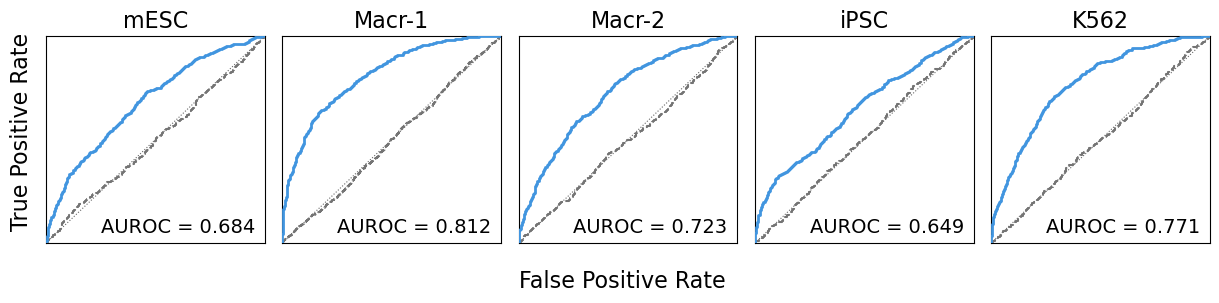

In [72]:
models_to_plot = ["E7.5_rep1", "buffer_1", "buffer_2", "WT_D13_rep1", "sample_1"]

sample_to_title_map = {
    "E7.5_rep1": "mESC",
    "buffer_1": "Macr-1",
    "buffer_2": "Macr-2",
    "WT_D13_rep1": "iPSC",
    "sample_1": "K562"
}

combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(models_to_plot),
    figsize=(12, 3),
    sharex=True,
    sharey=True,
)

roc_line_color = "#4195df"
rand_line_color = "#747474"

for ax, selected_model in zip(combined_axes, models_to_plot):

    matching_titles = [
        title for title in all_plot_data.keys()
        if f"{selected_model} Model" in title and f"{selected_model} Test Set" in title
    ]

    if len(matching_titles) == 0:
        ax.axis("off")
        ax.set_title(f"{selected_model}\nMissing", fontsize=10)
        continue

    title = matching_titles[0]

    labels = all_plot_data[title][0]
    scores = all_plot_data[title][1]

    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    fpr, tpr, _ = roc_curve(labels, scores)
    auroc = roc_auc_score(labels, scores)

    rand_scores = plotting_utils._create_random_distribution(scores)
    rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)
    rand_auroc = roc_auc_score(labels, rand_scores)

    ax.plot(
        fpr,
        tpr,
        lw=2,
        color=roc_line_color,
        label=f"AUROC = {auroc:.3f}",
        zorder=3,
    )

    ax.plot(
        rand_fpr,
        rand_tpr,
        color=rand_line_color,
        linestyle="--",
        lw=1.5,
        label=f"Random = {rand_auroc:.3f}",
        zorder=2,
    )

    ax.plot(
        [0, 1],
        [0, 1],
        color="black",
        linestyle=":",
        lw=0.8,
        alpha=0.6,
        zorder=1,
    )

    ax.set_title(sample_to_title_map.get(selected_model, selected_model), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    ax.text(
        0.25,
        0.05,
        f"AUROC = {auroc:.3f}",
        transform=ax.transAxes,
        fontsize=14,
        bbox=dict(facecolor="none", edgecolor="none"),
    )

    ax.tick_params(bottom=False, left=False)
    ax.set_xticklabels([])
    ax.set_yticklabels([])

# combined_fig.suptitle("Model vs Test Set", fontsize=14, y=1.05)

combined_fig.text(
    0.5,
    -0.02,
    "False Positive Rate",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.5,
    "True Positive Rate",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.02,
    right=0.99,
    bottom=0.13,
    top=0.82,
    wspace=0.08,
)

plt.show()

combined_fig.savefig(all_evaluation_plot_dir / f"models_vs_own_test_set.png", dpi=300, bbox_inches="tight")

### ROC - All models vs all test sets

In [134]:
model_samples = [
    "E7.5_rep1",
    "E7.5_rep2",
    "E8.5_rep1",
    "E8.5_rep2",
    "WT_D13_rep1",
    "buffer_1",
    "buffer_2",
    "buffer_3",
    "buffer_4",
    "sample_1",
]

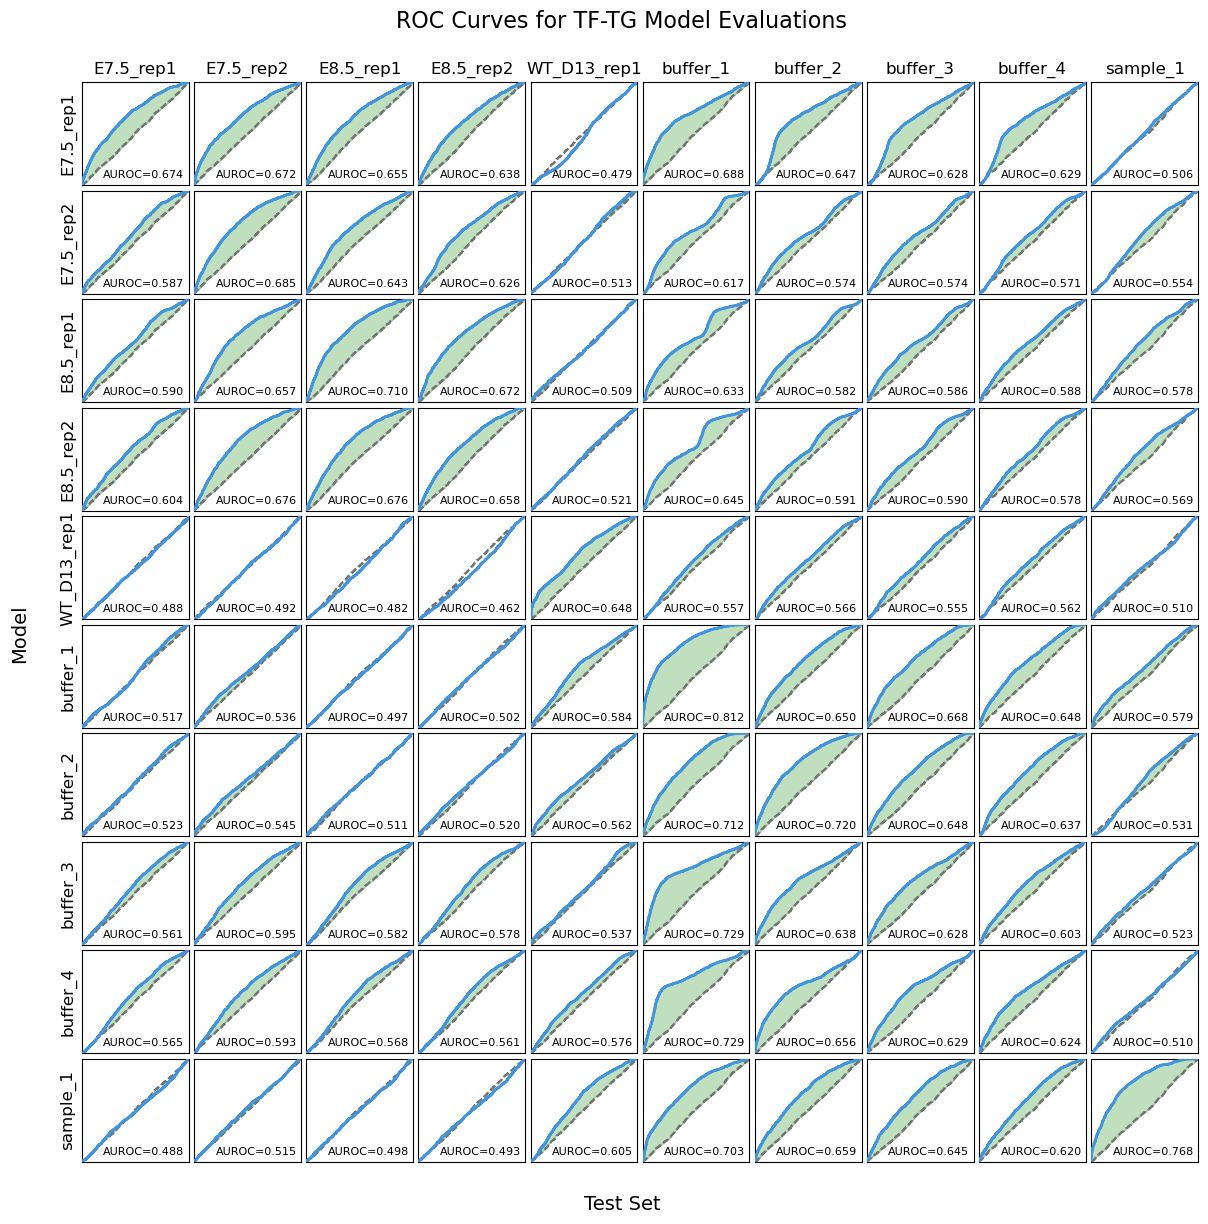

In [135]:
fig, axes = plt.subplots(
    nrows=len(model_samples),
    ncols=len(model_samples),
    figsize=(12, 12),
    sharex=True,
    sharey=True,
)

for i, model_sample in enumerate(model_samples):
    for j, test_sample in enumerate(model_samples):

        ax = axes[i, j]

        matching_titles = [
            key for key in all_plot_data
            if f"{model_sample} Model" in key and f"{test_sample} Test Set" in key
        ]

        if len(matching_titles) == 0:
            ax.axis("off")
            continue

        title = matching_titles[0]

        if title not in all_plot_data:
            ax.axis("off")
            ax.set_title("Missing", fontsize=8)
            continue

        labels = all_plot_data[title][0]
        scores = all_plot_data[title][1]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()

        fpr, tpr, _ = roc_curve(labels, scores)
        auroc = roc_auc_score(labels, scores)

        rand_scores = plotting_utils._create_random_distribution(scores)
        rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)

        ax.plot(
            fpr,
            tpr,
            lw=2,
            color="#4195df",
            zorder=3,
        )

        ax.plot(
            rand_fpr,
            rand_tpr,
            color="#747474",
            linestyle="--",
            lw=1.5,
            zorder=2,
        )
        
        # Interpolate random TPR onto model FPR grid
        rand_tpr_interp = np.interp(fpr, rand_fpr, rand_tpr)

        # Fill only where model ROC is above random ROC
        ax.fill_between(
            fpr,
            tpr,
            rand_tpr_interp,
            where=(tpr > rand_tpr_interp),
            interpolate=True,
            color="green",
            alpha=0.25,
            zorder=1,
        )

        # ax.plot(
        #     [0, 1],
        #     [0, 1],
        #     color="black",
        #     linestyle=":",
        #     lw=0.8,
        #     zorder=1,
        # )

        ax.text(
            0.20,
            0.07,
            f"AUROC={auroc:.3f}",
            transform=ax.transAxes,
            fontsize=8,
            bbox=dict(facecolor="none", edgecolor="none"),
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.tick_params(bottom=False, left=False, right=False)

        if i == 0:
            ax.set_title(test_sample, fontsize=12, ha="center")

        if j == 0:
            ax.set_ylabel(model_sample, fontsize=12)
            ax.set_yticks([])

        if i == len(model_samples) - 1:
            ax.set_xlabel("")
            ax.set_xticks([])

fig.suptitle("ROC Curves for TF-TG Model Evaluations", fontsize=16, y=1.02)

fig.text(
    0.5,
    0.02,
    "Test Set",
    ha="center",
    fontsize=14,
)

fig.text(
    -0.01,
    0.5,
    "Model",
    va="center",
    rotation="vertical",
    fontsize=14,
)

fig.subplots_adjust(
    left=0.05,
    right=0.98,
    bottom=0.06,
    top=0.96,
    wspace=0.05,
    hspace=0.05,
)
plt.show()

fig.savefig(all_evaluation_plot_dir / "model_vs_test_set_roc_curves.png", dpi=300, bbox_inches="tight")


### PRC - All models vs all test sets

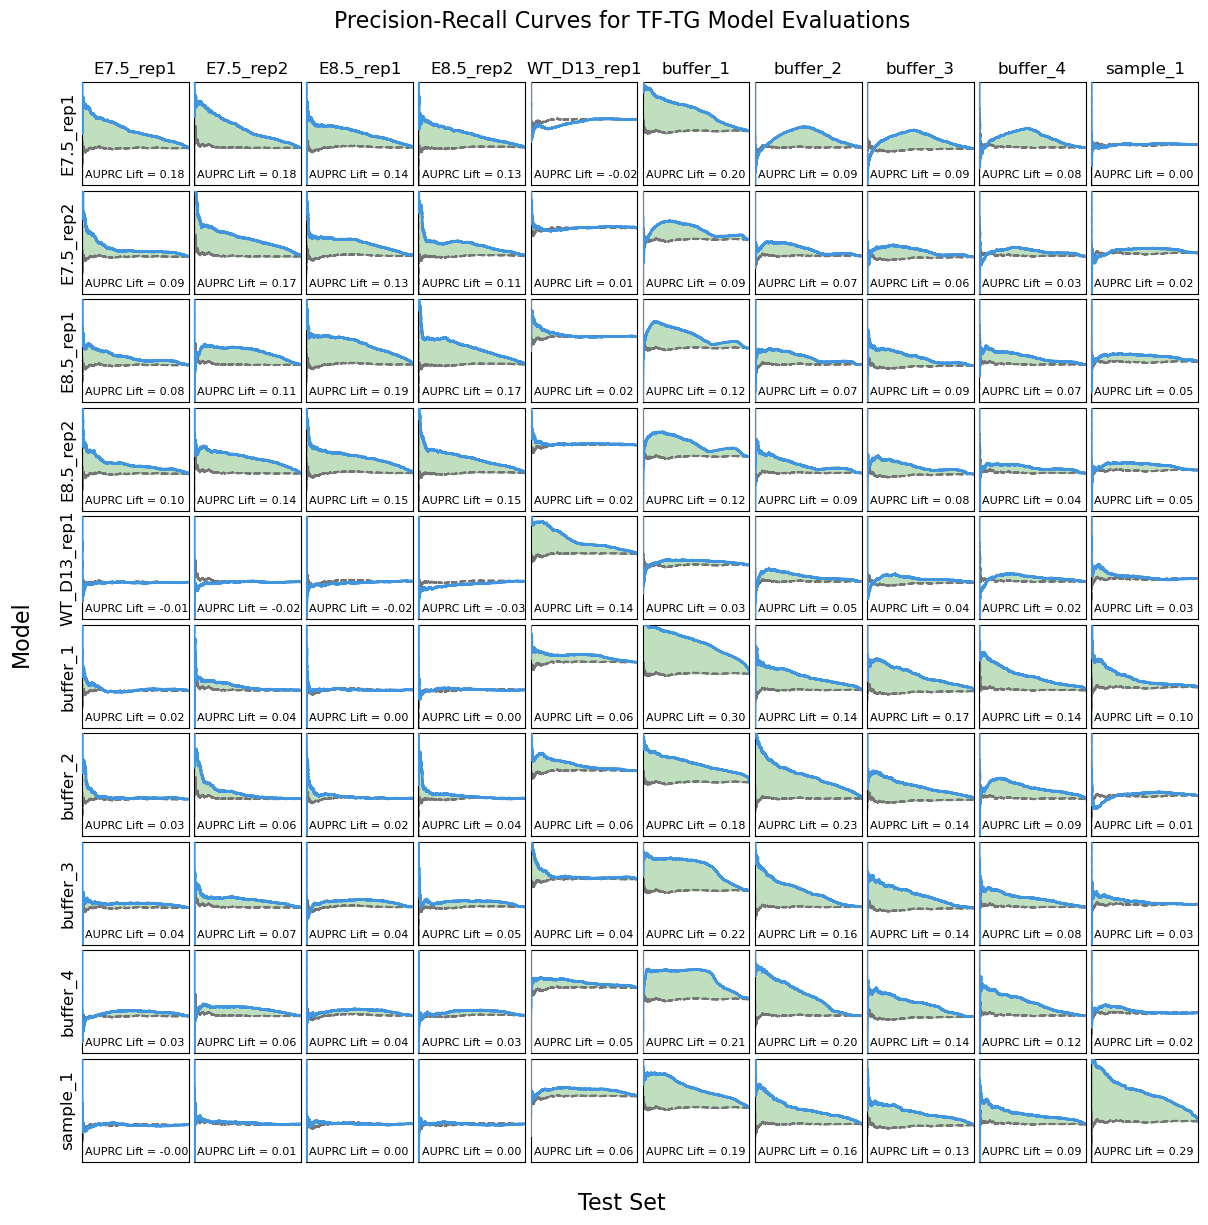

In [138]:
fig, axes = plt.subplots(
    nrows=len(model_samples),
    ncols=len(model_samples),
    figsize=(12, 12),
    sharex=True,
    sharey=True,
)

for i, model_sample in enumerate(model_samples):
    for j, test_sample in enumerate(model_samples):

        ax = axes[i, j]

        matching_titles = [
            key for key in all_plot_data
            if f"{model_sample} Model" in key and f"{test_sample} Test Set" in key
        ]

        if len(matching_titles) == 0:
            ax.axis("off")
            continue

        title = matching_titles[0]

        if title not in all_plot_data:
            ax.axis("off")
            ax.set_title("Missing", fontsize=8)
            continue

        labels = all_plot_data[title][0]
        scores = all_plot_data[title][1]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()
        
        prec, rec, _ = precision_recall_curve(labels, scores)
        auprc = average_precision_score(labels, scores)

        rand_prec, rand_rec, _ = precision_recall_curve(labels, rand_scores)
        rand_auprc = average_precision_score(labels, rand_scores)
        
        auprc_lift = auprc - rand_auprc
        
        order = np.argsort(rand_rec)
        rand_rec_sorted = rand_rec[order]
        rand_prec_sorted = rand_prec[order]

        ax.plot(
            rec,
            prec,
            lw=2,
            color="#4195df",
            zorder=3,
        )

        ax.plot(
            rand_rec,
            rand_prec,
            color="#747474",
            linestyle="--",
            lw=1.5,
            zorder=2,
        )
        
        # Interpolate random recall onto model grid
        rand_prec_interp = np.interp(rec, rand_rec_sorted, rand_prec_sorted)

        # Fill only where model AUPRC is above random AUPRC
        ax.fill_between(
            rec,
            prec,
            rand_prec_interp,
            where=(prec > rand_prec_interp),
            interpolate=True,
            color="green",
            alpha=0.25,
            zorder=1,
        )

        # ax.plot(
        #     [0, 1],
        #     [0, 1],
        #     color="black",
        #     linestyle=":",
        #     lw=0.8,
        #     zorder=1,
        # )

        ax.text(
            0.03,
            0.07,
            f"AUPRC Lift = {auprc_lift:.2f}",
            transform=ax.transAxes,
            fontsize=8,
            bbox=dict(facecolor="none", edgecolor="none"),
        )

        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.tick_params(bottom=False, left=False, right=False)

        if i == 0:
            ax.set_title(test_sample, fontsize=12, ha="center")

        if j == 0:
            ax.set_ylabel(model_sample, fontsize=12)
            ax.set_yticks([])

        if i == len(model_samples) - 1:
            ax.set_xlabel("")
            ax.set_xticks([])

fig.suptitle("Precision-Recall Curves for TF-TG Model Evaluations", fontsize=16, y=1.02)

fig.text(
    0.5,
    0.02,
    "Test Set",
    ha="center",
    fontsize=16,
)

fig.text(
    -0.01,
    0.5,
    "Model",
    va="center",
    rotation="vertical",
    fontsize=16,
)

fig.subplots_adjust(
    left=0.05,
    right=0.98,
    bottom=0.06,
    top=0.96,
    wspace=0.05,
    hspace=0.05,
)
plt.show()

fig.savefig(all_evaluation_plot_dir / "model_vs_test_set_pr_curves.png", dpi=300, bbox_inches="tight")


### Evaluation metrics

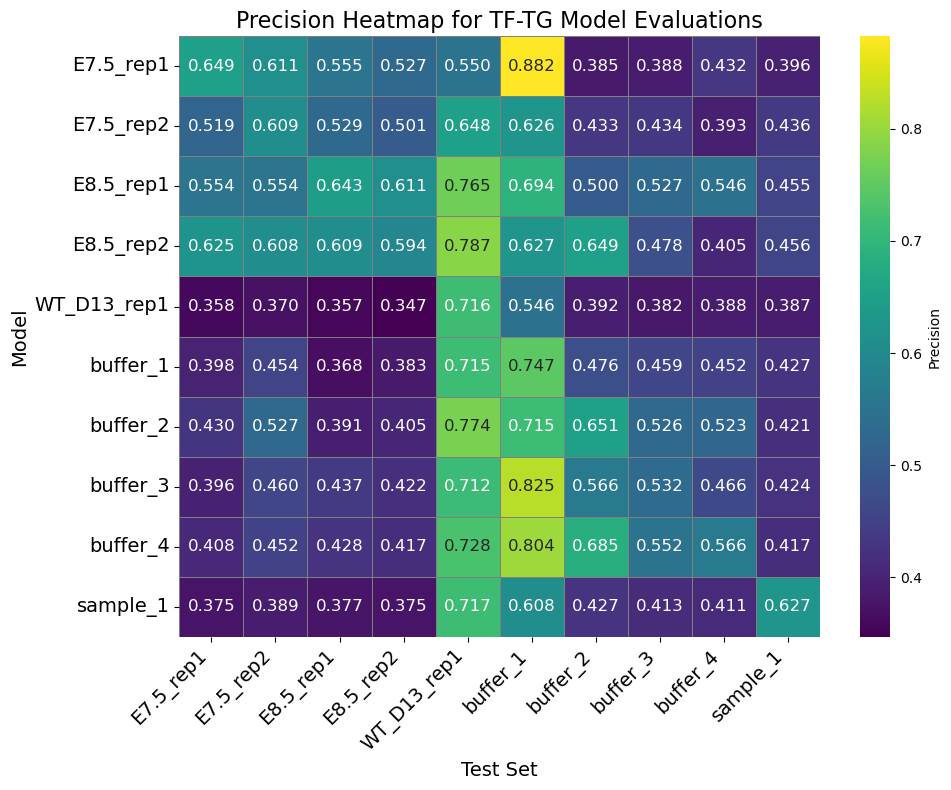

In [148]:
# Heatmap of AUROC values for each model vs test set combination
selected_metric = "Precision"
test_comparison_df = full_comparison_df.copy()

test_comparison_df["AUPRC Lift"] = test_comparison_df["auprc"] - test_comparison_df["rand_auprc"]
test_comparison_df = test_comparison_df.rename(columns={
    "auroc": "AUROC", 
    "auprc": "AUPRC",
    "accuracy": "Accuracy",
    "precision": "Precision",
    "recall": "Recall",
    })

test_comparison_df = test_comparison_df[["Model", "Test Set", selected_metric]]

test_comparison_df_pivot = test_comparison_df.pivot(index="Model", columns="Test Set", values=selected_metric)

fig = plt.figure(figsize=(10, 8))
heatmap_fig = sns.heatmap(
    test_comparison_df_pivot,
    annot=True,
    fmt=".3f",
    cmap="viridis",
    cbar_kws={'label': selected_metric},
    linewidths=0.5,
    linecolor='gray',
    annot_kws={"size": 12}
)
heatmap_fig.set_title(f"{selected_metric} Heatmap for TF-TG Model Evaluations", fontsize=16)
heatmap_fig.set_xlabel("Test Set", fontsize=14)
heatmap_fig.set_ylabel("Model", fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=14)
plt.yticks(rotation=0, fontsize=14)
plt.tight_layout()
plt.show()

fig.savefig(all_evaluation_plot_dir / f"model_vs_test_set_{selected_metric.lower().replace(' ', '_')}_heatmap.png", dpi=300, bbox_inches="tight")

## Model data shapes

In [82]:
evaluation_cell_type = "mESC"
model_training_sample = "E7.5_rep1"
evaluation_sample = "E7.5_rep1"

print(f"Model {model_training_sample} | Test set {evaluation_sample}")

tf_tg_model_chkpt = tf_tg_model_checkpoints[evaluation_cell_type][model_training_sample]
tf_dna_model_chkpt = tf_dna_model_checkpoints[evaluation_cell_type]

# print(f"Loading TF→TG model")
dataset_split_type = "test"
subset_size = 5000

cell_type_cache_dir = DATA_DIR / f"{evaluation_cell_type}_cache"

# print(f"Loading cached dataset with subset size: {subset_size}")
data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
    sample_name=evaluation_sample,
    cell_type_cache_dir=cell_type_cache_dir,
    split_type=dataset_split_type,
    subset_size=subset_size
    )

tf_tg_model = load_tf_tg_regulation_model(tf_dna_model_chkpt, tf_tg_model_chkpt, tf_embeddings_tensor, tf_mask_tensor)

# print("Moving model to device")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = tf_tg_model.model

Model E7.5_rep1 | Test set E7.5_rep1


In [ ]:
def shape_of(x):
    if torch.is_tensor(x):
        return tuple(x.shape)
    if isinstance(x, dict):
        return {k: shape_of(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [shape_of(v) for v in x]
    if x is None:
        return None
    return type(x).__name__


def make_shape_hook(name):
    def hook(module, args, kwargs, output):
        print(f"\n{name}")
        print(f"  args  : {shape_of(args)}")
        print(f"  module: {type(module).__name__}")
        print(f"  kwargs: {shape_of(kwargs)}")
        print(f"  output: {shape_of(output)}")
    return hook


model = tf_tg_model.model.to(device)
model.eval()

hook_names = {
    "tf_peak_model.tf_encoder",
    "tf_peak_model.peak_encoder",
    "tf_peak_model.cross_attn",
    "tf_peak_model.classifier",
    "peak_feature_proj",
    "tf_expr_proj",
    "tg_expr_proj",
    "tg_query_proj",
    "peak_attention",
    "norm",
    "classifier",
}

# Clear old hooks aggressively in notebook debugging
for module in model.modules():
    module._forward_hooks.clear()
    module._forward_pre_hooks.clear()
    module._backward_hooks.clear()

hooks = []
for name, module in model.named_modules():
    if name in hook_names:
        hooks.append(
            module.register_forward_hook(
                make_shape_hook(name),
                with_kwargs=True,
            )
        )
        
batch = next(iter(data_loader))
batch = tf_to_tg_module.move_batch_to_device(batch, device)

print("\nBatch input shapes:")
for k, v in batch.items():
    if torch.is_tensor(v):
        print(f"  {k}: {tuple(v.shape)}")

with torch.no_grad():
    edge_logits, aux_outputs = model(
        tf_embedding=batch["tf_embedding"],
        tf_mask=batch["tf_mask"],
        peak_sequences=batch["peak_sequences"],
        peak_accessibility=batch["peak_accessibility"],
        peak_distance=batch["peak_distance"],
        tf_expression=batch["tf_expression"],
        tg_expression=batch["tg_expression"],
        peak_mask=batch.get("peak_mask", None),
        cell_mask=batch["cell_mask"],
        pooling_mode="lse",
        pooling_temperature=1.0,
    )

print("\nFinal outputs:")
print("  edge_logits:", tuple(edge_logits.shape))
print("  aux_outputs:", shape_of(aux_outputs))

for h in hooks:
    h.remove()

## Test model performance vs other inference methods

### Functions

In [17]:
def generate_model_predictions(model, data_loader, device, tf_idx_to_name, tg_idx_to_name):
    pooling_mode = "lse"
    pooling_temperature = 1.0

    model = model.to(device)
    model.eval()
    
    if device.type == "cuda":
        model = torch.compile(model, mode="reduce-overhead")

    tf_indices_list = []
    tg_indices_list = []
    all_scores = []

    with torch.inference_mode():
        for batch in tqdm(data_loader, desc="Evaluating", ncols=100):
            tf_indices = batch["tf_idx"].detach().cpu().numpy().ravel()
            tg_indices = batch["tg_idx"].detach().cpu().numpy().ravel()

            batch = tf_to_tg_module.move_batch_to_device(batch, device)

            with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
                edge_logits, _ = model(
                    tf_embedding=batch["tf_embedding"],
                    tf_mask=batch["tf_mask"],
                    peak_sequences=batch["peak_sequences"],
                    peak_accessibility=batch["peak_accessibility"],
                    peak_distance=batch["peak_distance"],
                    tf_expression=batch["tf_expression"],
                    tg_expression=batch["tg_expression"],
                    peak_mask=batch.get("peak_mask", None),
                    cell_mask=batch["cell_mask"],
                    pooling_mode=pooling_mode,
                    pooling_temperature=pooling_temperature,
                )

            scores = torch.sigmoid(edge_logits.float())

            tf_indices_list.append(tf_indices)
            tg_indices_list.append(tg_indices)
            all_scores.append(scores.detach().cpu().numpy().ravel())

    all_tf_indices_flat = np.concatenate(tf_indices_list)
    all_tg_indices_flat = np.concatenate(tg_indices_list)
    all_scores_flat = np.concatenate(all_scores)

    tf_names = [tf_idx_to_name[int(idx)].capitalize() for idx in all_tf_indices_flat]
    tg_names = [tg_idx_to_name[int(idx)].capitalize() for idx in all_tg_indices_flat]

    prediction_df = pd.DataFrame({
        "Source": tf_names,
        "Target": tg_names,
        "Score": all_scores_flat,
    })

    prediction_df = (
        prediction_df.groupby(["Source", "Target"], as_index=False)["Score"]
        .median()
    )

    return prediction_df

def create_tf_tg_index_to_name_mappings(metadata):
    tf_idx_to_name = {idx: name for name, idx in metadata["tf_name_to_idx"].items()}
    tg_idx_to_name = {idx: name for name, idx in metadata["tg_id_to_idx"].items()}
    return tf_idx_to_name, tg_idx_to_name

def create_tf_tg_label_df(tftg_inputs_test):
    # Create the TF-TG label DataFrame
    tftg_inputs_test.keys()
    test_tf_input = tftg_inputs_test["tf_name"]
    test_tg_input = tftg_inputs_test["tg_name"]
    test_labels = tftg_inputs_test["label"]

    # create TF-TG label DataFrame
    tf_tg_label_df = pd.DataFrame({
        "Source": test_tf_input,
        "Target": test_tg_input,
        "Label": test_labels,
    })

    tf_tg_label_df = tf_tg_label_df.drop_duplicates(["Source", "Target"])

    gt_df: pd.DataFrame = tf_tg_label_df[tf_tg_label_df["Label"] == 1] 
    gt_tfs = set(gt_df["Source"].str.capitalize().unique()) 
    gt_targets = set(gt_df["Target"].str.capitalize().unique()) 
    gt_pairs = set(gt_df["Source"].str.capitalize() + "\t" + gt_df["Target"].str.capitalize())
    
    return tf_tg_label_df, gt_pairs, gt_tfs, gt_targets

def load_and_standardize_method(name: str, info: dict) -> pd.DataFrame:
    """
    Load a GRN CSV and rename tf_col/target_col/score_col -> Source/Target/Score.
    Extra columns are preserved.
    """
    if info["path"].suffix == ".tsv":
        sep = "\t"
    elif info["path"].suffix == ".csv":
        sep = ","
    
    df = pd.read_csv(info["path"], sep=sep, header=0, index_col=None)

    tf_col     = info["tf_col"]
    target_col = info["target_col"]
    score_col  = info["score_col"]

    rename_map = {
        tf_col: "Source",
        target_col: "Target",
        score_col: "Score",
    }

    missing = [c for c in rename_map if c not in df.columns]
    if missing:
        raise ValueError(f"[{name}] Missing expected columns: {missing}. Got: {list(df.columns)}")

    df = df.rename(columns=rename_map)

    df = df[["Source", "Target", "Score"]]
    df["Source"] = df["Source"].astype(str).str.capitalize()
    df["Target"] = df["Target"].astype(str).str.capitalize()
    
    df["Score"] = np.abs(df["Score"])

    return df

def precision_at_k(y_true, y_score, k=10_000):
    """Compute precision at k for binary classification/ranking problems."""
    # Sort the scores in descending order and get their corresponding true labels
    top_k_indices = np.argsort(y_score)[::-1][:k]
    top_k_labels = np.array(y_true)[top_k_indices]
    
    # Calculate precision in top K
    return np.sum(top_k_labels == 1) / k

def compute_metrics(method_name: str, sample_name: str, df: pd.DataFrame, gt_pairs: set, score_threshold: float):            
    labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
    scores = df["Score"].tolist()
    
    labels = np.asarray(labels).astype(int).ravel()
    scores = np.asarray(scores).astype(float).ravel()

    preds = (scores >= score_threshold).astype(int)

    early_precision = precision_at_k(labels, scores, k=10_000)
    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds, zero_division=0)
    recall = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)

    if len(np.unique(labels)) < 2:
        auroc = np.nan
    else:
        auroc = roc_auc_score(labels, scores)

    return pd.DataFrame([{
        "method_name": method_name,
        "sample_name": sample_name,
        "auroc": auroc,
        "early_precision": early_precision,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_edges": len(labels),
        "n_pos": int(labels.sum()),
        "n_neg": int((labels == 0).sum()),
        "score_threshold": score_threshold,
    }])
    
def build_full_universe_from_gt(method_df, gt_edges, use_abs_scores=True, missing_score=0.0):
    universe_tfs = gt_edges["Source"].dropna().unique()
    universe_tgs = gt_edges["Target"].dropna().unique()

    gt_pairs = set(zip(gt_edges["Source"], gt_edges["Target"]))

    full_universe = (
        pd.MultiIndex
        .from_product([universe_tfs, universe_tgs], names=["Source", "Target"])
        .to_frame(index=False)
    )

    full_universe["_in_gt"] = [
        1 if pair in gt_pairs else 0
        for pair in zip(full_universe["Source"], full_universe["Target"])
    ]

    method_scores = method_df[["Source", "Target", "Score"]].copy()

    if use_abs_scores:
        method_scores["Score"] = method_scores["Score"].abs()

    # If method has duplicate Source-Target edges, keep strongest score
    method_scores = (
        method_scores
        .sort_values("Score", ascending=False)
        .drop_duplicates(["Source", "Target"], keep="first")
    )

    full_universe = full_universe.merge(
        method_scores,
        on=["Source", "Target"],
        how="left",
    )

    full_universe["Score"] = full_universe["Score"].fillna(missing_score)

    # print(f"Complete TF-target universe size: {len(full_universe):,}")
    # print(
    #     f"Positives in universe: {(full_universe['_in_gt'] == 1).sum():,}"
    #     f" | Negatives: {(full_universe['_in_gt'] == 0).sum():,}"
    # )

    return full_universe

### Generate predictions and load other method GRNs

In [74]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision("high")

samples_to_run = [
    ("mESC", "E7.5_rep1"),
    ("Macrophage", "buffer_1"),
    ("Macrophage", "buffer_2"),
    ("K562", "sample_1"),
    ("iPSC", "WT_D13_rep1"),
]

cross_model_cell_type = "mESC"
cross_model_sample_name = "E8.5_rep1"

standardized_method_dfs = {}

label_by_method_dict = {}
score_by_method_dict = {}

metric_by_method_list = []

eval_metric_result_dir = RESULT_DIR / "evaluation_metrics"
eval_metric_result_dir.mkdir(exist_ok=True)

gt_by_sample_dict = {}

subset_size = None
for model_cell_type, sample_name in samples_to_run:
    
    logging.info(f"Processing sample: {sample_name} | Dataset: {model_cell_type}")
    
    cell_type_cache_dir = DATA_DIR / f"{model_cell_type}_cache"

    use_val = ["sample_1"]
    if sample_name in use_val:
        split_type = "val"
    else:
        split_type = "test"
    
    # Load the cached test dataset
    data_loader, metadata, manifest, tf_embeddings_tensor, tf_mask_tensor = load_training_cache_dataset(
        sample_name=sample_name,
        cell_type_cache_dir=cell_type_cache_dir,
        split_type=split_type,
        subset_size=subset_size
        )

    # Create the TF and TG index to name mappings
    tftg_inputs_test = torch.load(
        cell_type_cache_dir / "tf_tg_training_cache" / sample_name / f"tftg_inputs_{split_type}.pt",
        weights_only=False,
    )

    tf_idx_to_name, tg_idx_to_name = create_tf_tg_index_to_name_mappings(metadata)

    test_set_tf_indices = list(tftg_inputs_test['tf_idx'].numpy())
    test_set_tg_indices = list(tftg_inputs_test['tg_idx'].numpy())
    
    tf_names = [tf_idx_to_name[int(idx)].capitalize() for idx in test_set_tf_indices]
    tg_names = [tg_idx_to_name[int(idx)].capitalize() for idx in test_set_tg_indices]

    cross_model_chkpt = tf_tg_model_checkpoints[cross_model_cell_type][cross_model_sample_name]
    
    tf_tg_model_chkpt = tf_tg_model_checkpoints[model_cell_type][sample_name]
    tf_dna_model_chkpt = tf_dna_model_checkpoints[model_cell_type]

    # Load the TF→TG model
    tf_tg_model = load_tf_tg_regulation_model(
        tf_dna_model_chkpt, 
        tf_tg_model_chkpt, 
        tf_embeddings_tensor, 
        tf_mask_tensor
        )
    
    cross_tf_tg_model = load_tf_tg_regulation_model(
        tf_dna_model_chkpt,
        cross_model_chkpt,
        tf_embeddings_tensor,
        tf_mask_tensor,
    )

    # Generate the model predictions for the test set and create a DataFrame with TF names, TG names, and predicted scores
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    prediction_df = generate_model_predictions(tf_tg_model.model, data_loader, device, tf_idx_to_name, tg_idx_to_name)
    cross_model_prediction_df = generate_model_predictions(cross_tf_tg_model.model, data_loader, device, tf_idx_to_name, tg_idx_to_name)

    # # Create the labeled ground truth DataFrame for the test set
    tf_tg_label_df, gt_pairs, gt_tfs, gt_targets = create_tf_tg_label_df(tftg_inputs_test)
    
    # Only keep TFs, TGs, and pairs that are present in both the ground truth and the method predictions to ensure fair metric computation
    gt_tfs = gt_tfs.intersection(set(tf_names))
    gt_targets = gt_targets.intersection(set(tg_names))
    gt_pairs = set(pair for pair in gt_pairs if pair.split("\t")[0] in gt_tfs and pair.split("\t")[1] in gt_targets)
    
    gt_by_sample_dict[sample_name] = (gt_pairs, gt_tfs, gt_targets)

    OTHER_METHOD_MUON_DIR = Path("/gpfs/Labs/Uzun/DATA/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/other_method_grns")

    other_method_grns = {}
    
    linger_path       = OTHER_METHOD_MUON_DIR / "LINGER_muon" / f"linger_{model_cell_type}_{sample_name}.tsv"
    scenic_plus_path  = OTHER_METHOD_MUON_DIR / "SCENIC_muon" / f"scenicplus_{model_cell_type}_{sample_name}.tsv"
    cell_oracle_path  = OTHER_METHOD_MUON_DIR / "CellOracle_muon" / f"celloracle_{model_cell_type}_{sample_name}.tsv"
    pando_path        = OTHER_METHOD_MUON_DIR / "Pando_muon" / f"pando_{model_cell_type}_{sample_name}.tsv"
    figr_path         = OTHER_METHOD_MUON_DIR / "FigR_muon" / f"figr_{model_cell_type}_{sample_name}.tsv"

    method_info = {
        "SCENIC+":    {"path": scenic_plus_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "LINGER":     {"path": linger_path,      "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "CellOracle": {"path": cell_oracle_path, "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "Pando":      {"path": pando_path,       "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
        "FigR":       {"path": figr_path,        "tf_col": "Source",    "target_col": "Target",    "score_col": "Score"},
    }
    
    standardized_method_dfs[sample_name] = {}
    
    for method_name, info in method_info.items():
        df_std = load_and_standardize_method(method_name, info)
                
        # Filter the inferred GRN to only include edges where both the TF and TG are present in 
        # the test set ground truth
        
        mask = df_std["Source"].isin(gt_tfs) & df_std["Target"].isin(gt_targets)
        df_filtered: pd.DataFrame = df_std.loc[mask]
        
        # Sample the same number of edges for fair comparison
        if subset_size is not None:
            df_filtered = df_filtered.sample(n=min(df_filtered.shape[0], subset_size))
        
        standardized_method_dfs[sample_name][method_name] = df_filtered
        
    # Add the TF-TG model predictions to the standardized_method_dfs for metric computation
    standardized_method_dfs[sample_name]["MTGRN-STM"] = prediction_df
    standardized_method_dfs[sample_name]["MTGRN-CTM"] = cross_model_prediction_df

    label_by_method_dict[sample_name] = {}
    score_by_method_dict[sample_name] = {}
    
    # Compute metrics for each method and print results
    for method_name, df in standardized_method_dfs[sample_name].items():
        labels = [1 if pair in gt_pairs else 0 for pair in df["Source"] + "\t" + df["Target"]]
        scores = df["Score"].tolist()
        
        label_by_method_dict[sample_name][method_name] = labels
        score_by_method_dict[sample_name][method_name] = scores

        metrics_df = compute_metrics(method_name, sample_name, df, gt_pairs, score_threshold=0.5)
        metric_by_method_list.append(metrics_df)
        
        sample_metric_df_path = eval_metric_result_dir / model_cell_type / sample_name / f"{method_name}_{sample_name}_metrics.csv"
        sample_metric_df_path.parent.mkdir(parents=True, exist_ok=True)
        metrics_df.to_csv(sample_metric_df_path, index=False)
        
full_metric_df = pd.concat(metric_by_method_list, ignore_index=True)
full_metric_df.to_csv(eval_metric_result_dir / "full_method_comparison_metrics.csv", index=False)

INFO - Processing sample: E7.5_rep1 | Dataset: mESC
Evaluating: 100%|███████████████████████████████████████████████| 1883/1883 [09:31<00:00,  3.30it/s]
INFO - Processing sample: buffer_1 | Dataset: Macrophage
Evaluating: 100%|█████████████████████████████████████████████████| 118/118 [00:36<00:00,  3.23it/s]
INFO - Processing sample: buffer_2 | Dataset: Macrophage
Evaluating: 100%|█████████████████████████████████████████████████| 336/336 [01:14<00:00,  4.53it/s]
INFO - Processing sample: sample_1 | Dataset: K562
Evaluating: 100%|███████████████████████████████████████████████| 1135/1135 [04:09<00:00,  4.55it/s]
INFO - Processing sample: WT_D13_rep1 | Dataset: iPSC
Evaluating: 100%|███████████████████████████████████████████████| 1569/1569 [04:35<00:00,  5.69it/s]


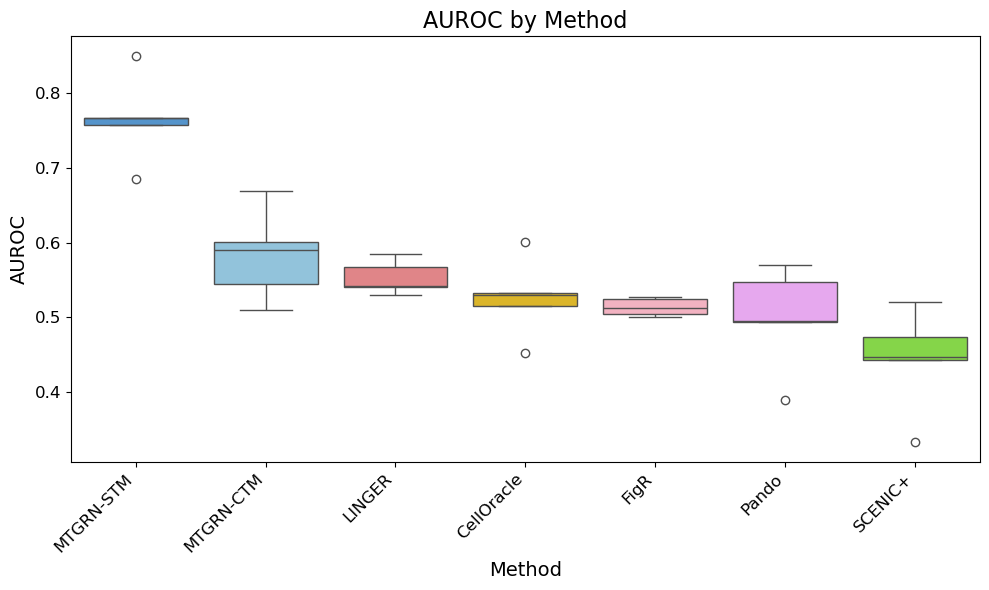

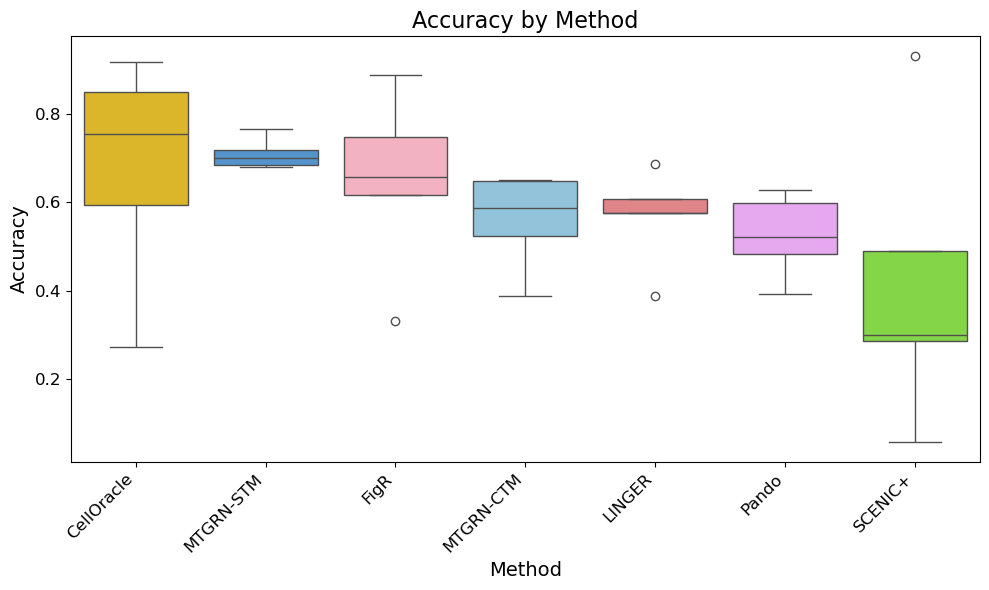

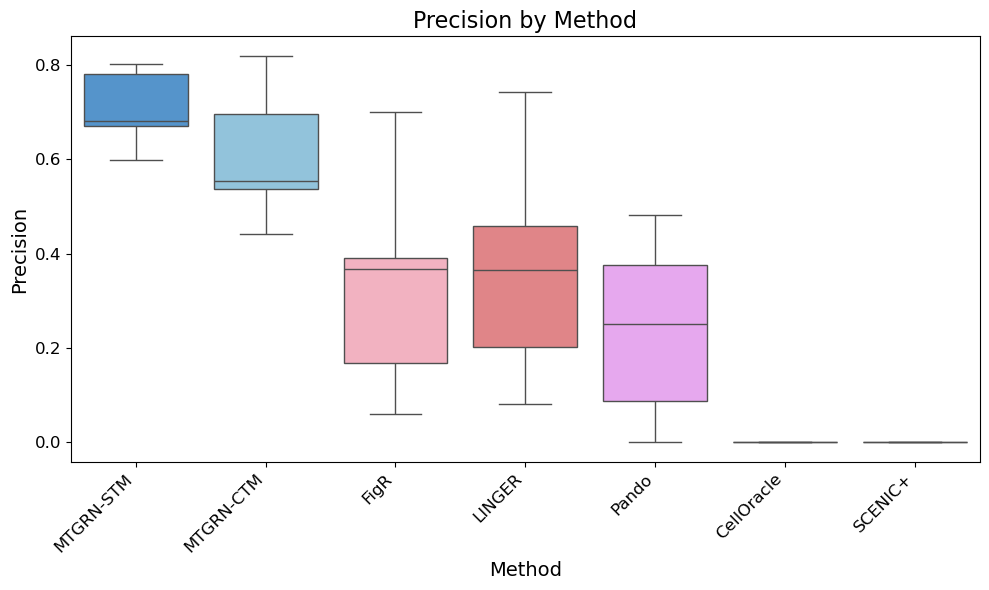

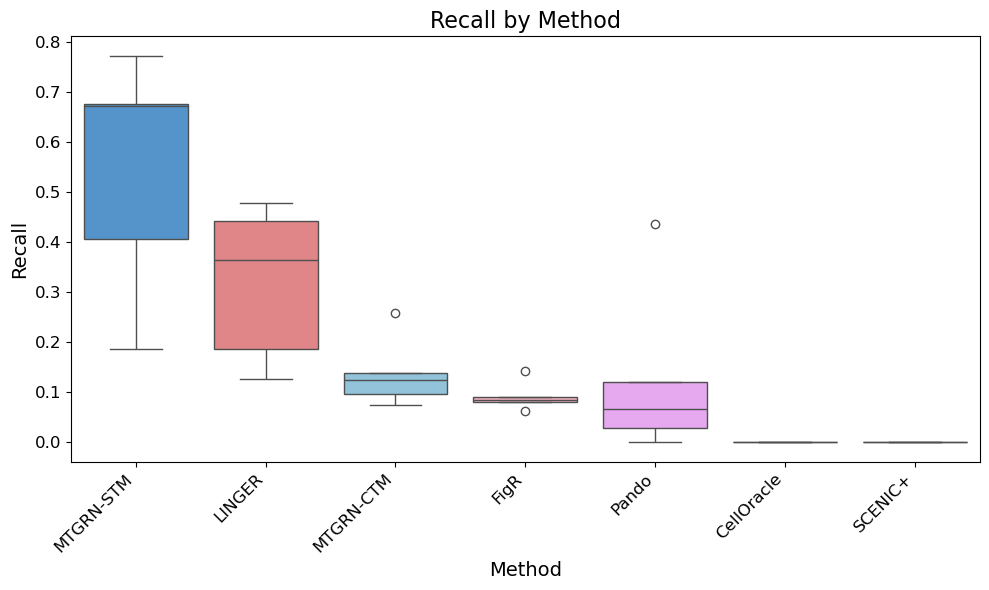

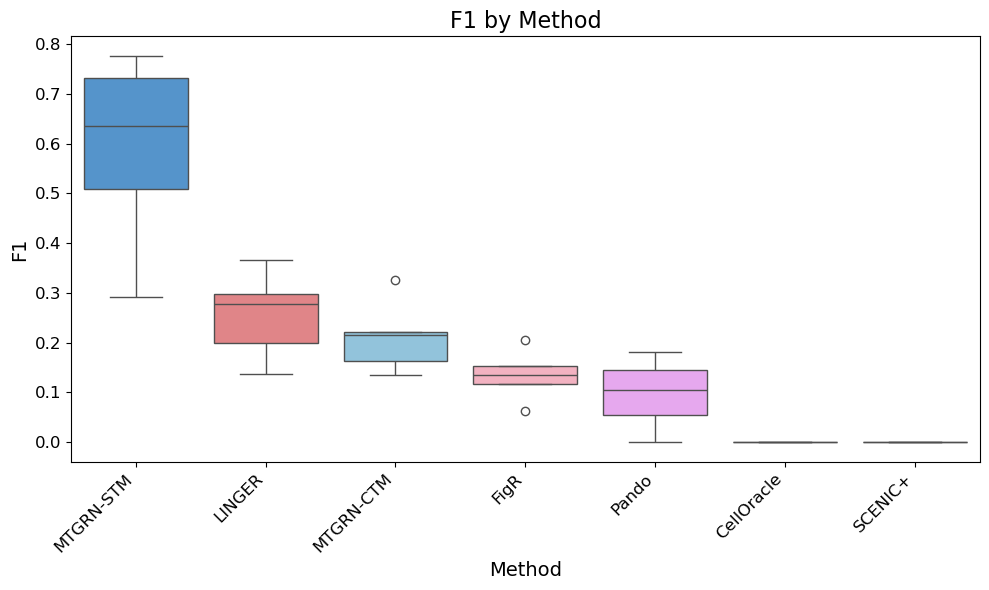

In [85]:
method_color_dict = {
  "MTGRN-STM": "#4195df",
  "MTGRN-CTM": "#86C7E7",
  "LINGER": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "SCENIC+": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

# Selected columns by method box and whisker plot
methods = ["auroc", "accuracy", "precision", "recall", "f1"]

for selected_column in methods:
    metric_ordered_by_auroc = (
        full_metric_df
        .groupby("method_name")[selected_column]
        .median()
        .sort_values(ascending=False)
        .index
        .tolist()
    )

    sanitized_name = selected_column.replace(" ", "_").lower()
    if sanitized_name in ["auroc", "auprc"]:
        sanitized_name = sanitized_name.upper()
    else:
        sanitized_name = sanitized_name.capitalize()

    plt.figure(figsize=(10, 6))
    sns.boxplot(data=full_metric_df, x="method_name", y=selected_column, hue = "method_name", order=metric_ordered_by_auroc, palette=method_color_dict)
    plt.title(f"{sanitized_name} by Method", fontsize=16)
    plt.xlabel("Method", fontsize=14)
    plt.ylabel(sanitized_name, fontsize=14)
    plt.xticks(rotation=45, ha='right', fontsize=12)
    plt.yticks(fontsize=12)
    plt.tight_layout()
    
    plt.savefig(eval_metric_result_dir / f"{sanitized_name.lower()}_by_method_boxplot.png", dpi=300, bbox_inches="tight")
    
    plt.show()

### Plot ROC curves

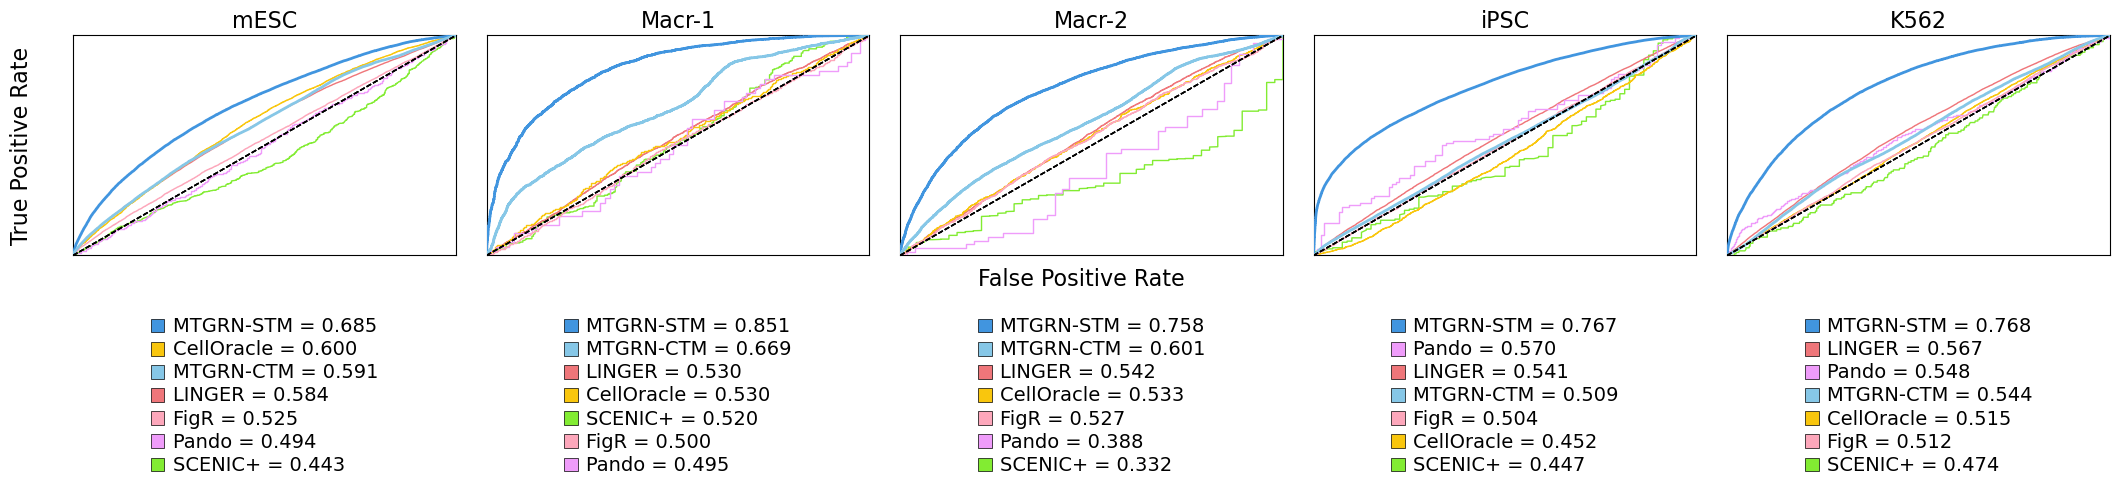

In [76]:
sample_to_title_map = {
    "E7.5_rep1": "mESC",
    "buffer_1": "Macr-1",
    "buffer_2": "Macr-2",
    "WT_D13_rep1": "iPSC",
    "sample_1": "K562"
}

method_color_dict = {
  "MTGRN-STM": "#4195df",
  "MTGRN-CTM": "#86C7E7",
  "LINGER": "#EF767A",
  "CellOracle": "#F9C60D",
  "Pando": "#EF9CFA",
  "SCENIC+": "#82EC32",
  "FigR": "#FDA7BB",
  "GRaNIE": "#F98637"
}

combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(sample_to_title_map),
    figsize=(4 * len(sample_to_title_map)+1, 5),
    sharex=True,
    sharey=True,
    squeeze=False,
)
combined_axes = np.array(combined_axes, ndmin=1).ravel()

cell_type_method_auroc = {}
for i, sample_name in enumerate(sample_to_title_map.keys()):
    
    ax = combined_axes[i]
    
    auroc_text_lines = []
    cell_type_method_auroc[sample_name] = {}
    
    for method in label_by_method_dict[sample_name].keys():
        labels = label_by_method_dict[sample_name][method]
        scores = score_by_method_dict[sample_name][method]

        labels = np.asarray(labels).astype(int).ravel()
        scores = np.asarray(scores).astype(float).ravel()

        fpr, tpr, _ = roc_curve(labels, scores)
        auroc = roc_auc_score(labels, scores)
        cell_type_method_auroc[sample_name][method] = auroc

        rand_scores = plotting_utils._create_random_distribution(scores)
        rand_fpr, rand_tpr, _ = roc_curve(labels, rand_scores)
        rand_auroc = roc_auc_score(labels, rand_scores)
        
        method_color = method_color_dict.get(method, "#747474")
        auroc_text_lines.append((method, auroc, method_color))

        if method in ["MTGRN-STM", "MTGRN-CTM"]:
            line_weight = 2
            
        else:
            line_weight = 1
            
        roc_line_color = method_color_dict.get(method, "#747474")

        ax.plot(
            fpr,
            tpr,
            lw=line_weight,
            color=roc_line_color,
            label=f"{method} = {auroc:.3f}",
            zorder=3,
        )
        
        ax.plot(
            [0, 1],
            [0, 1],
            color="black",
            linestyle="--",
            lw=1,
            alpha=0.6,
            zorder=4,
        )
        
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        
        ax.set_xticks([])
        ax.set_yticks([])

    auroc_text_lines_sorted = sorted(
        auroc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )

    ax.set_title(sample_to_title_map.get(sample_name, sample_name), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    legend_rows = []

    for method, auroc, method_color in auroc_text_lines_sorted:
        # Small colored square
        color_box = DrawingArea(12, 12, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1), 10, 10,
                facecolor=method_color,
                edgecolor="black",
                linewidth=0.5,
            )
        )

        # Black text
        label_text = TextArea(
            f"{method} = {auroc:.3f}",
            textprops=dict(
                color="black",
                fontsize=14,
            ),
        )

        # Put square and text side-by-side
        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0,
            sep=4,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=3,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.0,
        frameon=False,
        bbox_to_anchor=(0.5, -0.25),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

combined_fig.text(
    0.5,
    0.32,
    "False Positive Rate",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.60,
    "True Positive Rate",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.02,
    right=0.99,
    bottom=0.38,
    top=0.82,
    wspace=0.08,
)

plt.show()

combined_fig.savefig(all_evaluation_plot_dir / f"models_vs_own_test_set_roc.png", dpi=300, bbox_inches="tight")

/tmp/ipykernel_2810044/1983160157.py:100: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, rotation=45, ha="right")


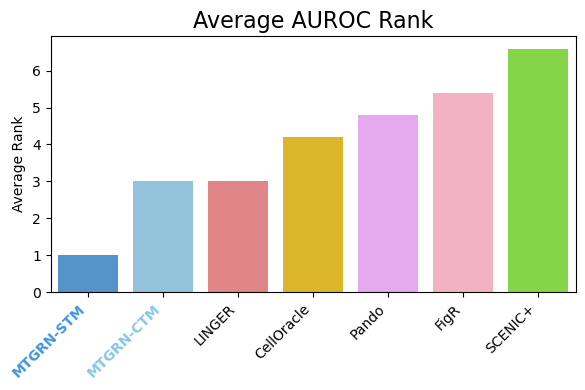

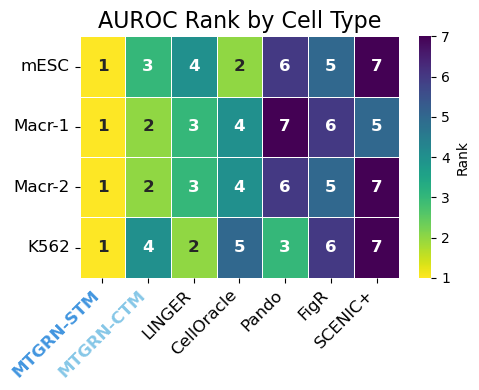

In [77]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def auroc_dict_to_long_df(cell_type_method_auroc):
    """
    Converts:
        {
            sample: {
                method: auroc,
                ...
            },
            ...
        }

    into a long dataframe with columns:
        experiment, method, auroc
    """
    rows = []

    for experiment, method_scores in cell_type_method_auroc.items():
        for method, auroc in method_scores.items():
            rows.append({
                "experiment": experiment,
                "method": method,
                "auroc": auroc,
            })

    return pd.DataFrame(rows)


def rank_methods_by_experiment(df):
    """
    Calculates method rank within each experiment/cell type.
    Higher AUROC = better rank.
    """
    all_ranks_df = df.copy()

    all_ranks_df["rank"] = (
        all_ranks_df
        .groupby("experiment")["auroc"]
        .rank(method="min", ascending=False)
        .astype(int)
    )

    return all_ranks_df.sort_values(["experiment", "rank"])


def avg_rank_by_method(all_ranks_df):
    """
    Calculates average rank for each method across experiments.
    Lower average rank = better.
    """
    rank_df = (
        all_ranks_df
        .groupby("method", as_index=False)
        .agg(avg_rank=("rank", "mean"))
        .sort_values("avg_rank", ascending=True)
        .reset_index(drop=True)
    )

    return rank_df


def avg_rank_by_method_plot(avg_rank_df, method_color_dict, title, rename_map=None):
    fig = plt.figure(figsize=(6, 4))

    if rename_map is None:
        rename_map = {}

    order = avg_rank_df["method"].tolist()

    sns.barplot(
        data=avg_rank_df,
        x="method",
        y="avg_rank",
        order=order,
        hue="method",
        palette=method_color_dict,
        dodge=False,
        legend=False,
    )

    ax = plt.gca()

    new_labels = []
    for tick in ax.get_xticklabels():
        original = tick.get_text()
        new = rename_map.get(original, original)
        new_labels.append(new)

        if new in {"MTGRN", "MTGRN-STM", "MTGRN-CTM"}:
            tick.set_color(method_color_dict.get(original, "black"))
            tick.set_fontweight("bold")
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")

    ax.set_xticklabels(new_labels, rotation=45, ha="right")

    ax.set_ylabel("Average Rank")
    ax.set_xlabel("")
    ax.set_title(title, fontsize=16)

    plt.tight_layout()
    return fig


def experiment_by_method_rank_heatmap(
    all_ranks_df,
    rank_df,
    method_color_dict,
    title=None,
    experiment_order=None,
    rename_map=None,
):
    if rename_map is None:
        rename_map = {}

    rank_heatmap_df = all_ranks_df.pivot(
        index="experiment",
        columns="method",
        values="rank",
    )

    method_order = rank_df["method"].tolist()

    if experiment_order is None:
        experiment_order = rank_heatmap_df.index.tolist()

    rank_heatmap_df = rank_heatmap_df.reindex(
        index=experiment_order,
        columns=method_order,
    )

    fig, ax = plt.subplots(figsize=(5, 4))

    sns.heatmap(
        rank_heatmap_df,
        annot=True,
        fmt=".0f",
        cmap="viridis_r",
        linewidths=0.5,
        linecolor="white",
        cbar_kws={"label": "Rank"},
        annot_kws={"size": 12, "fontweight": "bold"},
        ax=ax,
    )

    new_labels = []
    for tick in ax.get_xticklabels():
        original = tick.get_text()
        new = rename_map.get(original, original)
        new_labels.append(new)

        if new in {"MTGRN", "MTGRN-STM", "MTGRN-CTM"}:
            tick.set_color(method_color_dict.get(original, "black"))
            tick.set_fontweight("bold")
        else:
            tick.set_color("black")
            tick.set_fontweight("normal")
            
    # Rename y-axis experiment/sample labels
    new_y_labels = []
    for tick in ax.get_yticklabels():
        original = tick.get_text()
        new = rename_map.get(original, original)
        new_y_labels.append(new)

    ax.set_yticklabels(new_y_labels, rotation=0, fontsize=12)
    ax.set_xticklabels(new_labels, rotation=45, ha="right", fontsize=12)

    if title is None:
        ax.set_title("Method AUPRC Rank by Cell Type", fontsize=16)
    else:
        ax.set_title(title, fontsize=16)    
    
    ax.set_xlabel("")
    ax.set_ylabel("")

    plt.tight_layout()
    return fig

method_color_dict = {
    "MTGRN-STM": "#4195df",
    "MTGRN-CTM": "#86C7E7",
    "LINGER": "#EF767A",
    "CellOracle": "#F9C60D",
    "Pando": "#EF9CFA",
    "SCENIC+": "#82EC32",
    "FigR": "#FDA7BB",
}

experiment_order = [
    "E7.5_rep1",
    "buffer_1",
    "buffer_2",
    "sample_1",
]

rename_map = {
    "E7.5_rep1": "mESC",
    "buffer_1": "Macr-1",
    "buffer_2": "Macr-2",
    "sample_1": "K562",
}

auroc_df = auroc_dict_to_long_df(cell_type_method_auroc)

all_ranks_df = rank_methods_by_experiment(auroc_df)
rank_df = avg_rank_by_method(all_ranks_df)

avg_auroc_rank_fig = avg_rank_by_method_plot(
    rank_df,
    method_color_dict=method_color_dict,
    title="Average AUROC Rank",
)

auroc_heatmap_fig = experiment_by_method_rank_heatmap(
    all_ranks_df,
    rank_df,
    method_color_dict=method_color_dict,
    experiment_order=experiment_order,
    rename_map=rename_map,
    title="AUROC Rank by Cell Type",
)

avg_auroc_rank_fig.savefig(
    all_evaluation_plot_dir / "average_auroc_rank.png",
    dpi=300,
    bbox_inches="tight",
)

auroc_heatmap_fig.savefig(
    all_evaluation_plot_dir / "auroc_rank_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)


### Plot PR Curves

In [78]:
def normalize_gene_names(x):
    return pd.Series(list(x)).astype(str).str.strip().str.capitalize()


def make_gt_lookup(gt_tfs, gt_targets, gt_pairs):
    gt_tfs_norm = set(normalize_gene_names(gt_tfs))
    gt_targets_norm = set(normalize_gene_names(gt_targets))

    gt_pairs_norm = set()
    for pair in gt_pairs:
        src, tgt = str(pair).split("\t")
        src = str(src).strip().capitalize()
        tgt = str(tgt).strip().capitalize()
        gt_pairs_norm.add(f"{src}\t{tgt}")

    return gt_tfs_norm, gt_targets_norm, gt_pairs_norm


def make_full_universe(gt_tfs, gt_targets, gt_pairs):
    gt_tfs_norm, gt_targets_norm, gt_pairs_norm = make_gt_lookup(
        gt_tfs,
        gt_targets,
        gt_pairs,
    )

    full_universe = (
        pd.MultiIndex
        .from_product(
            [sorted(gt_tfs_norm), sorted(gt_targets_norm)],
            names=["Source", "Target"],
        )
        .to_frame(index=False)
    )

    full_universe["_edge_key"] = (
        full_universe["Source"].astype(str)
        + "\t"
        + full_universe["Target"].astype(str)
    )

    full_universe["_in_gt"] = (
        full_universe["_edge_key"]
        .isin(gt_pairs_norm)
        .astype("int8")
    )

    return full_universe, (gt_tfs_norm, gt_targets_norm, gt_pairs_norm)


def create_ground_truth_comparison_df(score_df, ground_truth_lookup, ground_truth_name):
    gt_tfs, gt_tgs, gt_pairs_set = ground_truth_lookup

    df = score_df.copy()

    df["Source"] = df["Source"].astype(str).str.strip().str.capitalize()
    df["Target"] = df["Target"].astype(str).str.strip().str.capitalize()

    mask = df["Source"].isin(gt_tfs) & df["Target"].isin(gt_tgs)
    df = df.loc[mask].copy()

    df["_edge_key"] = df["Source"] + "\t" + df["Target"]
    df["_in_gt"] = df["_edge_key"].isin(gt_pairs_set).astype("int8")
    df["ground_truth_name"] = ground_truth_name

    return df


def sample_auprc_10x_negatives(full_universe, random_state=42, neg_pos_ratio=10):
    positives = full_universe.loc[full_universe["_in_gt"] == 1].copy()
    negatives = full_universe.loc[full_universe["_in_gt"] == 0].copy()

    n_pos = len(positives)
    n_neg_sample = min(n_pos * neg_pos_ratio, len(negatives))

    if n_pos == 0 or n_neg_sample == 0:
        return full_universe.iloc[0:0].copy()

    neg_sampled = negatives.sample(
        n=n_neg_sample,
        replace=False,
        random_state=random_state,
    )

    auprc_df = pd.concat([positives, neg_sampled], axis=0)

    auprc_df = (
        auprc_df
        .sample(frac=1.0, random_state=random_state)
        .reset_index(drop=True)
    )

    return auprc_df

TFs: 52
TGs: 1930
Edges: 64178
E7.5_rep1 positives: 42725 negatives: 109722 baseline: 0.28026133672686243
buffer_1 positives: 3959 negatives: 19001 baseline: 0.17243031358885016
buffer_2 positives: 7767 negatives: 17545 baseline: 0.30685050568900124
WT_D13_rep1 positives: 64178 negatives: 36182 baseline: 0.63947787963332
sample_1 positives: 28074 negatives: 280740 baseline: 0.09090909090909091


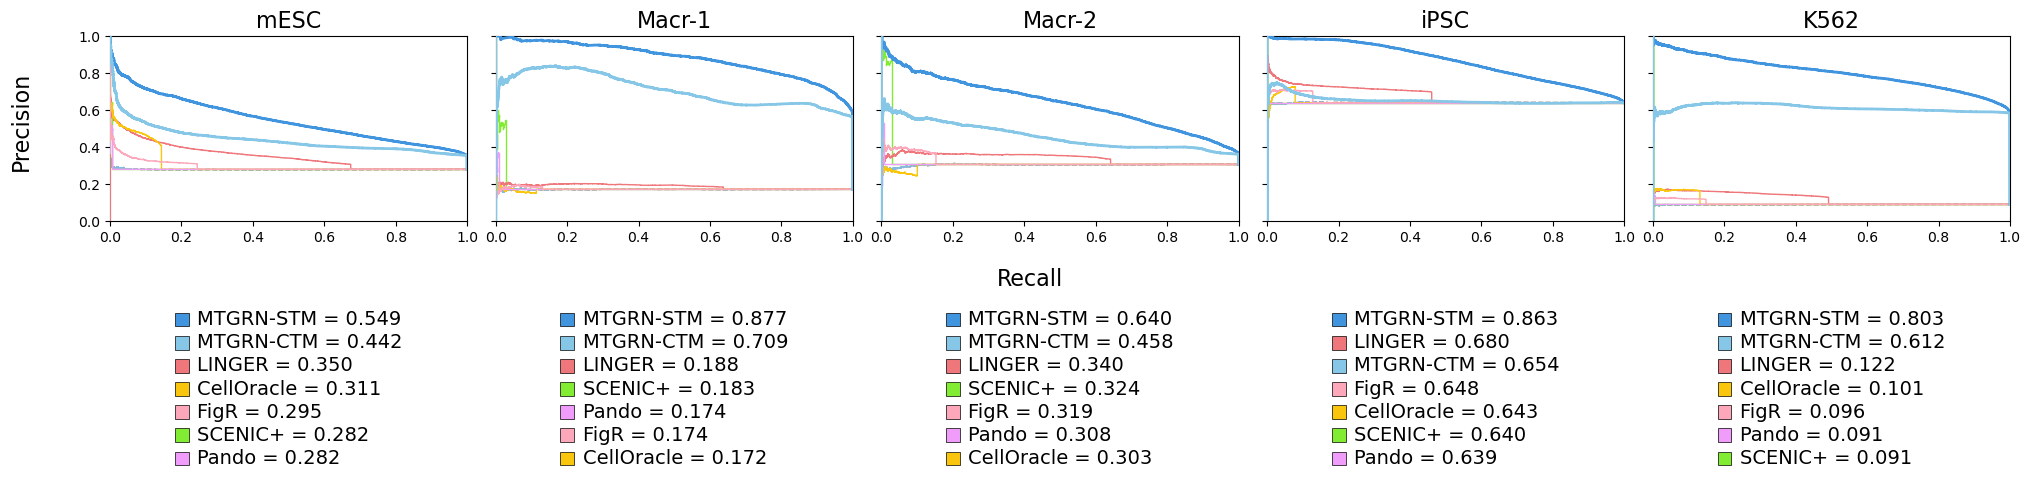

In [84]:
combined_fig, combined_axes = plt.subplots(
    nrows=1,
    ncols=len(sample_to_title_map),
    figsize=(4 * len(sample_to_title_map), 5),
    sharex=True,
    sharey=True,
    squeeze=False,
)

combined_axes = np.array(combined_axes, ndmin=1).ravel()

print(f"TFs: {len(gt_tfs)}")
print(f"TGs: {len(gt_targets)}")
print(f"Edges: {len(gt_pairs)}")

for i, sample_name in enumerate(sample_to_title_map.keys()):

    ax = combined_axes[i]
    auprc_text_lines = []

    # Use sample-specific GT
    gt_pairs_sample, gt_tfs_sample, gt_targets_sample = gt_by_sample_dict[sample_name]

    full_universe, gt_lookup = make_full_universe(
        gt_tfs=gt_tfs_sample,
        gt_targets=gt_targets_sample,
        gt_pairs=gt_pairs_sample,
    )

    full_universe_10x_negatives = sample_auprc_10x_negatives(
        full_universe,
        random_state=42,
        neg_pos_ratio=10,
    )

    eval_df = full_universe_10x_negatives[
        ["Source", "Target", "_in_gt"]
    ].copy()

    print(
        sample_name,
        "positives:",
        int(eval_df["_in_gt"].sum()),
        "negatives:",
        int((eval_df["_in_gt"] == 0).sum()),
        "baseline:",
        eval_df["_in_gt"].mean(),
    )

    for method in label_by_method_dict[sample_name].keys():

        # Use sample-specific method scores
        df_std = standardized_method_dfs[sample_name][method].copy()

        method_labeled_df = create_ground_truth_comparison_df(
            score_df=df_std,
            ground_truth_lookup=gt_lookup,
            ground_truth_name="test_chrom_gt",
        )

        method_scores = (
            method_labeled_df
            .groupby(["Source", "Target"], as_index=False)["Score"]
            .median()
        )

        auprc_df = eval_df.merge(
            method_scores,
            on=["Source", "Target"],
            how="left",
        )

        auprc_df["Score"] = auprc_df["Score"].fillna(0)

        y_auprc = auprc_df["_in_gt"].astype(int).to_numpy()
        s_auprc = auprc_df["Score"].astype(float).to_numpy()

        auprc = average_precision_score(y_auprc, s_auprc)
        prec, rec, _ = precision_recall_curve(y_auprc, s_auprc)

        rand_scores = plotting_utils._create_random_distribution(s_auprc)
        rand_prec, rand_rec, _ = precision_recall_curve(y_auprc, rand_scores)

        method_color = method_color_dict.get(method, "#747474")
        auprc_text_lines.append((method, auprc, method_color))

        line_weight = 2 if method in ["MTGRN-STM", "MTGRN-CTM"] else 1

        ax.step(
            rec,
            prec,
            where="post",
            lw=line_weight,
            color=method_color,
            label="",
            zorder=3,
        )

        ax.step(
            rand_rec,
            rand_prec,
            where="post",
            lw=1,
            linestyle="--",
            color=method_color,
            label="",
            zorder=2,
            alpha=0.75,
        )

    auprc_text_lines_sorted = sorted(
        auprc_text_lines,
        key=lambda x: x[1],
        reverse=True,
    )

    ax.set_title(sample_to_title_map.get(sample_name, sample_name), fontsize=16)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    legend_rows = []

    for method, auprc, method_color in auprc_text_lines_sorted:
        color_box = DrawingArea(12, 12, 0, 0)
        color_box.add_artist(
            Rectangle(
                (0, 1),
                10,
                10,
                facecolor=method_color,
                edgecolor="black",
                linewidth=0.5,
            )
        )

        label_text = TextArea(
            f"{method} = {auprc:.3f}",
            textprops=dict(
                color="black",
                fontsize=14,
            ),
        )

        row = HPacker(
            children=[color_box, label_text],
            align="center",
            pad=0,
            sep=4,
        )

        legend_rows.append(row)

    packed_legend = VPacker(
        children=legend_rows,
        align="left",
        pad=0,
        sep=3,
    )

    anchored_text = AnchoredOffsetbox(
        loc="upper center",
        child=packed_legend,
        pad=0.0,
        frameon=False,
        bbox_to_anchor=(0.5, -0.45),
        bbox_transform=ax.transAxes,
        borderpad=0.4,
    )

    ax.add_artist(anchored_text)

    # ax.tick_params(bottom=False, left=False)
    # ax.set_xticklabels([])
    # ax.set_yticklabels([])

combined_fig.text(
    0.5,
    0.32,
    "Recall",
    ha="center",
    fontsize=16,
)

combined_fig.text(
    -0.01,
    0.65,
    "Precision",
    va="center",
    rotation="vertical",
    fontsize=16,
)

combined_fig.subplots_adjust(
    left=0.04,
    right=0.99,
    bottom=0.45,
    top=0.82,
    wspace=0.08,
)

# plt.xlim([0, 0.02])

plt.show()

combined_fig.savefig(
    all_evaluation_plot_dir / "models_vs_own_test_set_prc.png",
    dpi=300,
    bbox_inches="tight",
)

### Karamveer's method for creating a ground truth evaluation

In [ ]:
def create_ground_truth_comparison_df(score_df, ground_truth_lookup, ground_truth_name):
    # Normalize once
    gt_tfs, gt_tgs, gt_pairs_set = ground_truth_lookup

    src = score_df["Source"]
    tgt = score_df["Target"]

    mask = src.isin(gt_tfs) & tgt.isin(gt_tgs)

    df = score_df.loc[mask].copy()
    # re-use normalized versions so we don't upper twice
    df["Source"] = src.loc[mask].values
    df["Target"] = tgt.loc[mask].values

    key = df["Source"] + "\t" + df["Target"]
    df["_in_gt"] = key.isin(gt_pairs_set).astype("int8")
    df["ground_truth_name"] = ground_truth_name

    return df

import scripts.build_tf_to_tg_train_data as tf_tg_data_builder
model_cell_type = "mESC"
sample_name = "E7.5_rep1"

# Load the full ground truth
cell_type_cache_dir = DATA_DIR / f"{model_cell_type}_cache"
merged_ground_truth_df = pd.read_parquet(cell_type_cache_dir / "merged_ground_truth.parquet")

project_data_dir = Path("/gpfs/Labs/Uzun/SCRIPTS/PROJECTS/2024.SINGLE_CELL_GRN_INFERENCE.MOELLER/data")
gene_reference_file = gene_ref_file = project_data_dir / "genome_data" / "genome_annotation" / "mm10" / "Mus_musculus.GRCm39.115.gtf.gz"

train_chroms = [str(i) for i in range(1, 16)]
val_chroms = [ str(i) for i in range(16, 18)]
test_chroms = [str(i) for i in range(18, 20)]

# Split genes into train/val/test based on chromosome
train_genes, val_genes, test_genes = tf_tg_data_builder.split_genes_by_chromosome(
    gene_ref_file,
    train_chroms=train_chroms,
    val_chroms=val_chroms,
    test_chroms=test_chroms
    )

gt_train_df, gt_val_df, gt_test_df = tf_tg_data_builder.create_train_val_test_splits(
    merged_ground_truth_df, train_genes, val_genes, test_genes
)

gt_test_df["Source"] = gt_test_df["Source"].astype(str).str.upper()
gt_test_df["Target"] = gt_test_df["Target"].astype(str).str.upper()

# Build TF, TG, and edge sets for quick lookup later
gt = gt_test_df[["Source", "Target"]].dropna()

gt_tfs = set(gt["Source"].unique())
gt_tgs = set(gt["Target"].unique())

gt_pairs = (gt["Source"] + "\t" + gt["Target"]).drop_duplicates()

gt_lookup = (gt_tfs, gt_tgs, set(gt_pairs))

INFO - Splitting genes into train/val/test based on chromosome:
INFO - Extracted GTF attributes: ['gene_id', 'gene_version', 'gene_name', 'gene_source', 'gene_biotype', 'transcript_id', 'transcript_version', 'transcript_name', 'transcript_source', 'transcript_biotype', 'tag', 'transcript_support_level', 'exon_number', 'exon_id', 'exon_version', 'protein_id', 'protein_version', 'ccds_id']
INFO -   - Train set: 62,426 genes (chroms 1-9)
INFO -   - Validation set: 5,700 genes (chroms 16-17)
INFO -   - Test set: 4,099 genes (chroms 18-19)
INFO - Train interactions: 6590425
INFO - Validation interactions: 580265
INFO - Test interactions: 480491


Test gt df shape: (480491, 2)


---

## Predictions per epoch

In [184]:
model_cell_type = "Macrophage"
model_training_sample = "buffer_3"

chkpt_dir = find_latest_checkpoint(model_cell_type, model_training_sample).parent
print(f"Using checkpoint directory: {chkpt_dir.name}")

chkpt_files = list(chkpt_dir.glob("epoch=*-val_auroc=*-val_loss=*.ckpt"))
if not chkpt_files:
    logging.warning(f"No checkpoint files found for {model_training_sample} in {chkpt_dir.name}")

chkpt_files.sort(key=lambda f: int(f.stem.split("-")[0].split("=")[1]), reverse=False)
chkpt_nums = [int(f.stem.split("-")[0].split("=")[1]) for f in chkpt_files]

# only plot every 10 epochs
chkpt_files = [f for f in chkpt_files if int(f.stem.split("-")[0].split("=")[1]) % 10 == 0]
print(f"Found {len(chkpt_files)} checkpoint files with epochs: {chkpt_nums[:2]} ... {chkpt_nums[-2:]}")

per_epoch_plot_data = {}
all_comparison_df_list = []
subset_size = 3000
for chkpt_file in tqdm(chkpt_files, desc="Evaluating Checkpoints", ncols=100):
    dataset_split_type = "val"
    
    epoch_num = int(chkpt_file.stem.split("-")[0].split("=")[1])
    
    tf_tg_model_checkpoints[model_cell_type][model_training_sample] = chkpt_file
    
    comparison_result = run_prediction_vs_test_set(
        model_cell_type=model_cell_type,
        model_training_sample=model_training_sample,
        test_set_cell_type=model_cell_type,
        evaluation_sample=model_training_sample,
        dataset_split_type=dataset_split_type,
        subset_size=subset_size,
        show_progress_bar=False,
    )
        
    metric_df = comparison_result["metric_df"]
    metric_df["epoch"] = epoch_num
    
    plot_data = comparison_result["plot_data"]
    
    all_labels_flat = plot_data[0]
    all_scores_flat = plot_data[1]
    
    title = f"{model_cell_type} {model_training_sample}\nEpoch {epoch_num}"
    
    per_epoch_plot_data[title] = (all_labels_flat, all_scores_flat)
    
    all_comparison_df_list.append(metric_df)
    
all_epoch_df = pd.concat(all_comparison_df_list, ignore_index=True)

            

INFO - Latest checkpoint for Macrophage buffer_3: Job 3696133 Epoch 126


Using checkpoint directory: tf_tg_train_buffer_3_3696133
Found 13 checkpoint files with epochs: [0, 1] ... [125, 126]


Plotting Histograms: 100%|██████████████████████████████████████████| 13/13 [00:02<00:00,  4.90it/s]


In [187]:

plot_dir = PROJECT_DIR / "plots" / "histogram_per_epoch" / f"{model_cell_type}_{model_training_sample}"
plot_dir.mkdir(parents=True, exist_ok=True)
(plot_dir / "epoch_figs").mkdir(parents=True, exist_ok=True)

for title in tqdm(per_epoch_plot_data.keys(), desc="Plotting Histograms", ncols=100):        
    labels = per_epoch_plot_data[title][0]
    scores = per_epoch_plot_data[title][1]
    
    epoch = int(title.split("\nEpoch ")[1])

    histogram_fig = plotting_utils.plot_score_histograms(
        labels=labels,
        scores=scores,
        n_bins=50,
        y_log=False,
        panel_kind="hist",
        density=False,
        title = title,
        y_lim=(0, 100),
        x_lim=(0, 1)
    )

    histogram_fig.savefig(plot_dir / "epoch_figs" / f"epoch_{epoch}.png")
    plt.close(histogram_fig)
    
# Combine all histogram plots into a GIF in epoch order
import imageio.v3 as iio
gif_path = plot_dir / f"{model_cell_type}_{model_training_sample}_histograms.gif"

filenames = sorted(plot_dir.glob("epoch_figs/epoch_*.png"), key=lambda f: int(f.stem.split("_")[1]))
images = [iio.imread(str(f)) for f in filenames]

default_duration = 200
# The lagging
lag = 2000
# Pause the GIF by extending the duration of the last frame
duration = [default_duration] * (len(images)-1) + [lag]
iio.imwrite(gif_path, images, duration=duration, loop=0)

Plotting Histograms: 100%|██████████████████████████████████████████| 13/13 [00:02<00:00,  6.49it/s]
